In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pandas as pd
import scipy
from scipy.signal import savgol_filter
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib as mpl
from tqdm.auto import tqdm, trange
import json
from multiprocessing import Pool
from functools import partial
from numpy.polynomial import Polynomial
import math
from astropy.coordinates import SkyCoord
import gc
from matplotlib.colors import Normalize
from astropy.visualization import ZScaleInterval
import warnings
warnings.filterwarnings("ignore")
import shutil
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from numba import njit, jit, prange
from numba_progress import ProgressBar

/home/bhanselman/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# **I. Filter Dataset**

In [ ]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed'
shutil.copytree('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed_old', data_dir, dirs_exist_ok=True)
for bank in range(10):
    bank_dir = os.path.join(data_dir, str(bank))
    for file in os.listdir(bank_dir):
        if int(file.split('_')[0]) < 57504:
            os.remove(os.path.join(bank_dir, file))

In [6]:
for bank in range(10):
    print(f'Bank {bank}: {len(os.listdir(os.path.join(data_dir, str(bank))))}')

Bank 0: 14175
Bank 1: 13750
Bank 2: 13403
Bank 3: 13564
Bank 4: 13513
Bank 5: 13395
Bank 6: 14521
Bank 7: 14524
Bank 8: 14490
Bank 9: 1855


## Correct normalized and cut datasets

In [8]:
norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized'
norm_cut_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_cut'
for case in ['decay', 'ann']:
    for bank in range(10):
        bank_norm_dir = os.path.join(norm_dir, case, str(bank))
        bank_norm_cut_dir = os.path.join(norm_cut_dir, case, str(bank))
        for file in os.listdir(bank_norm_dir):
            if int(file.split('_')[0]) < 57504:
                os.remove(os.path.join(bank_norm_dir, file))
        for file in os.listdir(bank_norm_cut_dir):
            if int(file.split('_')[0]) < 57504:
                os.remove(os.path.join(bank_norm_cut_dir, file))

# **II. Flattened Heatmaps**

## Plot function

In [2]:
plt.rcParams['font.size'] = 14

def plot_heatmap(info, xs, all_spectra, case, bank, start_freq=8000, width=100, n_bins=50, time=False, resid=False, cut=True):
    mask = (xs >= start_freq) & (xs < start_freq + width)
    nans = np.full(xs.shape, np.nan)[mask]
    end_freq = xs[mask][-1]

    info['time_mjd'] = info['time'].apply(lambda mjd: int(mjd.split('_')[0])) #[int(mjd.split('_')[0]) for mjd in info['time']]
    info['cos_theta'] = info['theta'].apply(lambda theta: math.cos(math.radians(theta))) #[math.cos(math.radians(theta)) for theta in info['theta']]
    info['cos_phi'] = info['phi'].apply(lambda phi: math.cos(math.radians(phi))) #[math.cos(math.radians(phi)) for phi in info['phi']]

    var_list = ['time_mjd'] if time else ['cos_theta', 'cos_phi']

    fig = plt.figure(figsize=(12, 6), layout="tight")
    gs = fig.add_gridspec(len(var_list), 2, wspace=0, hspace=0.2, width_ratios=[3, 1])
    axs = gs.subplots().flat

    def create_map(bin_column):
        for i in range(n_bins):
            bin_mask = (info[bin_column] == i).to_numpy()
            spectra = all_spectra[bin_mask][:, mask]
            if spectra.size:
                avg = np.nanmean(spectra, axis=0)
                yield avg
            else:
                yield nans

    for i, var in enumerate(var_list):
        bounds = (min(info['time_mjd']), max(info['time_mjd'])) if var == 'time_mjd' else (-1, 1)
        bins = np.linspace(*bounds, n_bins+1)
        info[f'{var}_bin'] = pd.cut(info[var], bins, labels=False)
            
        heat_map = np.array(list(create_map(f'{var}_bin')))
        if resid:
            heat_map = heat_map - np.nanmean(all_spectra[:, mask], axis=0)

        ax = axs[2*i]
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(np.array(heat_map))
        if resid is not None:
            vmax = max(vmax, -vmin)
            ndigits = -int(math.floor(math.log10(vmax))) + 1
            vmax = round(vmax, ndigits)
            vmin = -vmax
        else:
            vmax = max(vmax, 2-vmin)
            ndigits = -int(math.floor(math.log10(vmax - 1))) + 1
            vmax = round(vmax, ndigits)
            vmin = 2 - vmax
        norm = Normalize(vmin=vmin, vmax=vmax)
        extent = [np.min(xs[mask]), np.max(xs[mask]), *bounds]

        #im0 = axs[0].imshow(theta_map, extent=extent, origin='lower', norm=norm, aspect='auto')
        im1 = ax.imshow(heat_map, extent=extent, cmap='RdBu' if resid is not None else 'viridis', origin='lower', norm=norm, aspect='auto', interpolation='none')
        
        #axs[0].set_ylabel(r'$\mathrm{cos}({\theta})$', fontsize=18)
        if var == 'cos_phi':
            label = r'$\mathrm{cos}({\phi})$'
        elif var == 'cos_theta':
            label = r'$\mathrm{cos}({\theta})$'
        else:
            label = 'Modified JD'

        ax.set_ylabel(label, fontsize=18)
        # for i in bins:
        #     ax.axhline(i, c='r')

        hist_ax = axs[2*i+1]
        nan_mask = np.any(np.isfinite(all_spectra[:, mask]), axis=1)
        info_mask = info[nan_mask]
        hist_ax.hist(info_mask[var], bins=bins, facecolor='lightgray', edgecolor='k', orientation='horizontal')
        hist_ax.set_yticks([])
        hist_ax.set_ylim(*bounds)

        if var != 'time_mjd':
            ax.axhline(0, c='r') # Inward/outward division
            hist_ax.axhline(0, c='r') # Inward/outward division
            ax.set_yticks(np.linspace(-1, 1, 5))
    
    case_str = f'{case} cut' if cut else case
    fig.suptitle(f'Bank {bank} {case_str}: {start_freq:.0f}-{end_freq:.0f} MHz', fontsize=20)
    #ax.set_aspect('auto')

    axs[2*(len(var_list)-1)].set_xlabel(r'$\nu$ [MHz]', fontsize=18)
    axs[2*(len(var_list)-1)+1].set_xlabel('Counts', fontsize=18)

    cax = inset_axes(
        hist_ax,
        width="15%",
        height=f"{100 * len(var_list) + 20 * (len(var_list)-1)}%",
        loc="lower left",
        bbox_to_anchor=(1.05, 0., 1, 1),
        bbox_transform=hist_ax.transAxes,
        borderpad=0
    )
    cbar = fig.colorbar(im1, cax=cax, orientation='vertical')
    cbar.set_label('Normalized Power Residual' if resid is not None else 'Normalized Power', fontsize=18)
    
    return fig

## Theta/phi

In [3]:
norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized'
norm_cut_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_cut'

info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/all_lscx_info.csv'
info = pd.read_csv(info_dir, sep='\t')

cases = ['decay', 'ann']
banks = np.arange(10)

width = 187.5/2

date = '082126'

os.makedirs(f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/theta_phi', exist_ok=True)

def round_up_to_nearest_10(number):
    return math.ceil(number / 10) * 10

for case in cases:
    is_decay = case == 'decay'
    for cut in [True, False]:
        if cut:
            pdf_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/theta_phi/{case}_cut.pdf'
            data_dir = norm_cut_dir
        else:
            pdf_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/theta_phi/{case}.pdf'
            data_dir = norm_dir
        pdf = PdfPages(pdf_dir)
        
        for bank in banks:
            bank_dir = os.path.join(data_dir, case, str(bank))
            bank_info = info[info['time'].apply(lambda l: l+'.npy').isin(os.listdir(bank_dir))]
            
            xs = np.load(os.path.join(bank_dir, bank_info['time'].tolist()[0]+'.npy'))[0]
            all_spectra = np.array([
                np.load(os.path.join(bank_dir, file+'.npy'))[1]
                for file in bank_info['time']
            ])
            
            start_freqs = np.arange(xs[0], xs[-1], width)

            for start_freq in tqdm(start_freqs, desc=f'Bank {bank} {case} cut' if cut else f'Bank {bank} {case}'):
                fig = plot_heatmap(
                    bank_info,
                    xs,
                    all_spectra,
                    case,
                    bank,
                    start_freq=start_freq,
                    width=width,
                    resid=True,
                    cut=cut
                )
                pdf.savefig(fig, bbox_inches='tight', dpi=72)
                plt.close(fig)

        pdf.close()

Bank 0 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 1 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 2 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 3 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 4 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

...

Bank 5 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 6 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 7 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 8 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 9 ann:   0%|          | 0/16 [00:00<?, ?it/s]

## Time

In [4]:
norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized'
norm_cut_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_cut'

info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/all_lscx_info.csv'
info = pd.read_csv(info_dir, sep='\t')

cases = ['decay', 'ann']
banks = np.arange(10)

width = 187.5/2

date = '082126'

os.makedirs(f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/time', exist_ok=True)

def round_up_to_nearest_10(number):
    return math.ceil(number / 10) * 10

for case in cases:
    is_decay = case == 'decay'
    for cut in [True, False]:
        if cut:
            pdf_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/time/{case}_cut.pdf'
            data_dir = norm_cut_dir
        else:
            pdf_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/time/{case}.pdf'
            data_dir = norm_dir
        pdf = PdfPages(pdf_dir)
        
        for bank in banks:
            bank_dir = os.path.join(data_dir, case, str(bank))
            bank_info = info[info['time'].apply(lambda l: l+'.npy').isin(os.listdir(bank_dir))]
            
            xs = np.load(os.path.join(bank_dir, bank_info['time'].tolist()[0]+'.npy'))[0]
            all_spectra = np.array([
                np.load(os.path.join(bank_dir, file+'.npy'))[1]
                for file in bank_info['time']
            ])
            
            start_freqs = np.arange(xs[0], xs[-1], width)

            for start_freq in tqdm(start_freqs, desc=f'Bank {bank} {case} cut' if cut else f'Bank {bank} {case}'):
                fig = plot_heatmap(
                    bank_info,
                    xs,
                    all_spectra,
                    case,
                    bank,
                    start_freq=start_freq,
                    width=width,
                    resid=True,
                    time=True,
                    cut=cut
                )
                pdf.savefig(fig, bbox_inches='tight', dpi=72)
                plt.close(fig)

        pdf.close()

Bank 0 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 1 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 2 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 3 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 4 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

...

Bank 5 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 6 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 7 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 8 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 9 ann:   0%|          | 0/16 [00:00<?, ?it/s]

# **III. LCSX Dataset Plots**

0.5955586843752156
0.470491793550383
0.3971914642546474
0.428183412679432


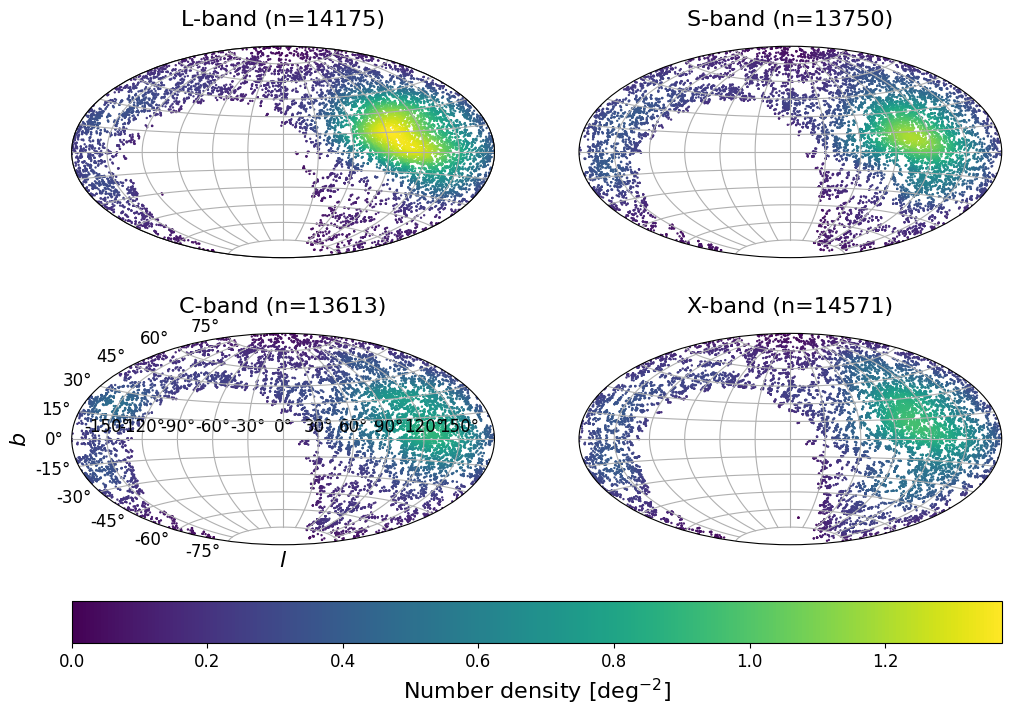

In [25]:
from scipy.stats import gaussian_kde

plt.rcParams['font.size'] = 12

info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/all_lscx_info.csv', sep='\t')
info = info[info['time'].apply(lambda x: int(x.split('_')[0]) >= 57504)]
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(3, 2, height_ratios=[6, 6, 1])

bands = ['L', 'S', 'C', 'X']
colors = plt.get_cmap('cividis')(np.linspace(0,1,4))

ax = fig.add_subplot(gs[0], projection='aitoff')
ax.grid(zorder=0)

maxs = []
for band in bands:
    band_info = info[info['band'] == band]
    gal = SkyCoord(band_info['l'], band_info['b'], unit='deg', frame='galactic')

    x = gal.l.wrap_at('180d').radian
    y = gal.b.radian

    xy = np.vstack([x,y])
    z = gaussian_kde(xy)(xy) * len(band_info) * (np.pi / 180) ** 2 # rad^-2 to deg^-2
    maxs.append(max(z))

norm = plt.Normalize(0, max(maxs))

for i in range(2):
    for j in range(2):
        idx = 2 * i + j
        band, color = bands[idx], colors[idx]

        ax = fig.add_subplot(gs[i,j], projection='aitoff')
        ax.grid(zorder=0)

        band_info = info[info['band'] == band]
        gal = SkyCoord(band_info['l'], band_info['b'], unit='deg', frame='galactic')

        x = gal.l.wrap_at('180d').radian
        y = gal.b.radian

        xy = np.vstack([x,y])
        z = gaussian_kde(xy)(xy) * len(band_info) * (np.pi / 180) ** 2 # rad^-2 to deg^-2
        print(np.mean(z))

        scatter = ax.scatter(x, y, c=z, norm=norm, s=0.5, zorder=1, label=band)

        ax.set_title(f'{band}-band (n={len(band_info)})', pad=15, fontsize=16)

        if idx != 2:
            ax.tick_params(axis='x', labelbottom=False)
            ax.tick_params(axis='y', labelleft=False)
        else:
            ax.set_xlabel('$l$', fontsize=16)
            ax.set_ylabel('$b$', fontsize=16)

axs = fig.axes
axs[0].tick_params(axis='y', labelleft=False)
cax = fig.add_subplot(gs[2, :])
cbar = fig.colorbar(scatter, cax=cax, orientation='horizontal')
cbar.set_label('Number density [deg$^{-2}$]', fontsize=16)

# handles = [Line2D([0], [0], marker='o', ls='None', color=color, label=band, markersize=10) for band, color in zip(bands, colors)]
# ax.legend(handles=handles, bbox_to_anchor=(0.2, 0.2), title='Band', ncols=2)
fig.savefig('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/mercator_bands.png', dpi=300)

# **IV. KL Transform Attempt**

## i. Gain spectrum counts

In [3]:
cal_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/calibrator_scans'
counts = {
    str(bank): len(os.listdir(os.path.join(cal_dir, str(bank))))
    for bank in range(10)
}
counts

{'0': 80,
 '1': 53,
 '2': 55,
 '3': 55,
 '4': 54,
 '5': 53,
 '6': 76,
 '7': 75,
 '8': 76,
 '9': 10}

In [4]:
# Gains only
counts = {
    str(bank): len([time for time in os.listdir(os.path.join(cal_dir, str(bank))) if os.path.exists(os.path.join(cal_dir, str(bank), time, 'gain.npy'))])
    for bank in range(10)
}
counts

{'0': 80,
 '1': 53,
 '2': 55,
 '3': 55,
 '4': 54,
 '5': 53,
 '6': 76,
 '7': 74,
 '8': 76,
 '9': 10}

Bank 7 has one missing gain, but that's it.

## ii. Gain plots

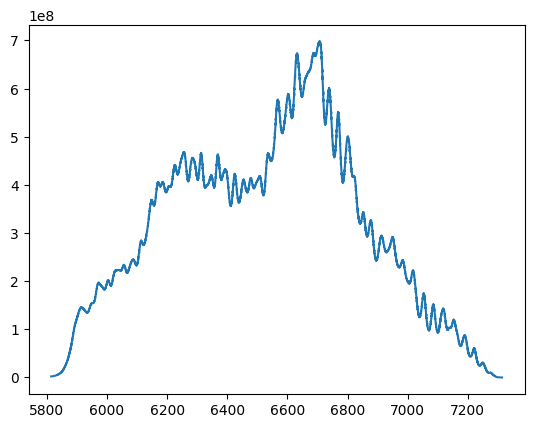

In [8]:
data = np.load('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/calibrator_scans/4/58803_47311/gain.npy')
plt.plot(*data)

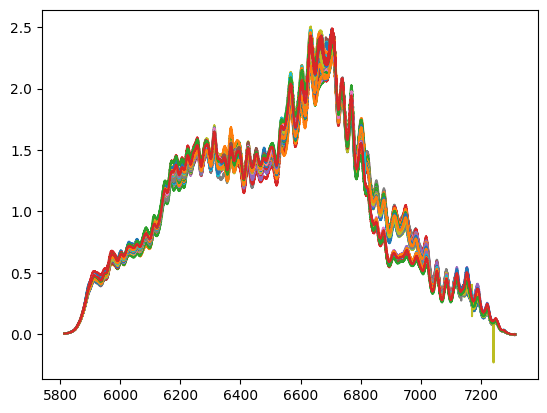

In [12]:
bank_4_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/calibrator_scans/4'
for time in os.listdir(bank_4_dir):
    data = np.load(os.path.join(bank_4_dir, time, 'gain.npy'))
    plt.plot(data[0], data[1] / np.mean(data[1]))

## iii. Normalize gains

### Normalize function (with prange)

In [5]:
from numba import jit, njit, prange

In [16]:
# Constants
c = 299792
v_virial = 250 # km/s
v_earth  = 225 # km/s

@njit
def _coeff_mat(x, deg):
    mat_ = np.zeros(shape=(x.shape[0],deg + 1))
    const = np.ones_like(x)
    mat_[:,0] = const
    mat_[:, 1] = x
    if deg > 1:
        for n in range(2, deg + 1):
            mat_[:, n] = x**n
    return mat_
    
@jit
def _fit_x(a, b):
    # linalg solves ax = b
    det_ = np.linalg.lstsq(a, b)[0]
    return det_
 
@jit
def fit_poly(x, y, deg, w=None):
    a = _coeff_mat(x, deg)
    if w is not None:
        a *= w[:, np.newaxis]
        y *= w
    p = _fit_x(a, y)
    return p

@jit
def eval_polynomial(p, x):
    '''
    Compute polynomial P(x) where P is a vector of coefficients, highest
    order coefficient at P[0].  Uses Horner's Method.
    '''
    result = 0
    for coeff in p[::-1]:
        result = x * result + coeff
    return result

@njit(cache=True)
def normalize_weighted_numba(data, a=0.1, b=1, exterior=3, order=5, is_decay=True, freq=None, width=200, start=None, stop=None):
    """
    Standard rolling polynomial normalize procedure. Updated.
    """
    xs, ys = data
    
    freq_diff = xs[1] - xs[0]
    ys_mean = ys / np.nanmean(ys)
    for i in range(16, len(ys)-16, 16):  # Excise the 4 unstable valley points in each coarse channel 
        ys_mean[i] = np.nan
        ys_mean[i+15] = np.nan
        ys_mean[i+1] = np.nan
        ys_mean[i+14] = np.nan
    
    xs_trimmed = xs
    if freq is not None:
        index = np.argmin(np.abs(xs - freq))
        width = int(width / freq_diff)
        xs_trimmed = xs[index-width:index+width+1]
    else:
        if start is not None or stop is not None:
            start_index = 0 if start is None else np.argmin(np.abs(xs - start))
            stop_index = len(xs) - 1 if stop is None else np.argmin(np.abs(xs - stop))
            xs_trimmed = xs[start_index:stop_index+1]
    
    new_xs = np.zeros(xs_trimmed.shape[0])
    normalized_spectrum = np.zeros(xs_trimmed.shape[0])
    
    def get_sigma(center):
        if is_decay:
            sigma = v_virial*center/(c*np.sqrt(3))
        else:
            sigma = v_virial*center/(c*np.sqrt(6))
        return sigma

    def round_up_to_nearest_odd(number):
        ceiled_number = math.ceil(number)
        return int(ceiled_number + 1) if ceiled_number % 2 == 0 else int(ceiled_number)

    # Loop through the data points and divide each point by the polynomial 
    for j in prange(len(xs_trimmed)):
        x = xs_trimmed[j]
        new_xs[j] = x
        #i = xs.tolist().index(x)
        i = np.where(xs == x)[0][0]
        window = round_up_to_nearest_odd(2 * exterior * get_sigma(x) / freq_diff)
        
        if (i < (window//2)) or (i >= len(xs) - (window//2 + 1)): 
            normalized_spectrum[j] = np.nan # 1
            continue

        ind_xs = np.arange(-(window//2), window//2+1).astype(np.float64)

        current_ys = ys_mean[i-window//2:i+window//2+1]
        idx = np.isfinite(current_ys)

        if np.all(~idx):
            normalized_spectrum[j] = np.nan
            continue
        
        # Unweighted fit
        #unweighted_params = np.polyfit(ind_xs[idx], current_ys[idx], order)
        unweighted_p = fit_poly(ind_xs[idx], current_ys[idx], order)
        
        # Weighted fit
        sigma = get_sigma(x)
        weights = 1 - a*np.exp(-(freq_diff*ind_xs[idx])**2 / (2*b*sigma**2))
        #weighted_params = np.polyfit(ind_xs[idx], current_ys[idx], order, w=weights)
        weighted_p = fit_poly(ind_xs[idx], current_ys[idx], order, w=weights)

        unweighted = eval_polynomial(unweighted_p, 0) #np.poly1d(unweighted_params)
        weighted = eval_polynomial(weighted_p, 0) #np.poly1d(weighted_params)

        normalized_spectrum[j] = unweighted/weighted
        
    #new_ys = ys_mean[lower: len(xs)-upper]
    normalized = np.zeros((2, new_xs.shape[0]))
    normalized[0] = new_xs
    normalized[1] = normalized_spectrum
    #old = np.array([new_xs, new_ys])

    return normalized

In [18]:
norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_gains/decay'

for bank in range(10):
    os.makedirs(os.path.join(norm_dir, str(bank)), exist_ok=True)
    bank_cal_dir = os.path.join(cal_dir, str(bank))
    for time in tqdm(os.listdir(bank_cal_dir)):
        path = os.path.join(bank_cal_dir, time, 'gain.npy')
        if os.path.exists(path):
            spec = np.load(path)
            norm_spec = normalize_weighted_numba(spec)
            np.save(os.path.join(norm_dir, str(bank), time + '.npy'), norm_spec)
            

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

  0%|          | 0/55 [00:00<?, ?it/s]

  0%|          | 0/55 [00:00<?, ?it/s]

  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

  0%|          | 0/76 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/76 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

## iv. KL transform implementation

In [ ]:
def klt(specs):
    '''
    Returns KL orthonormal basis for gain spectra.

    Inputs:
        specs: normalized gain spectral powers
    
    Returns:
        basis: Eigenspectra
    '''
    cov = np.cov(specs)
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    basis = np.dot(eigenvectors.T, specs)
    return basis

In [2]:
# Example: bank 4
bank_4_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_gains/decay/4'
specs = np.array([np.load(os.path.join(bank_4_dir, file))[1] for file in os.listdir(bank_4_dir)])
specs

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

(0.9999, 1.0001)

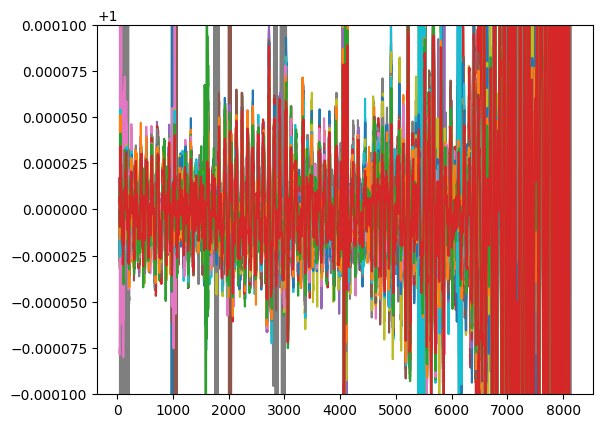

In [8]:
for spec in specs:
    plt.plot(spec)
plt.ylim(1-1e-4, 1+1e-4)

In [17]:
specs_test = specs[:, 4000:5000]
np.any(np.isnan(specs_test))

False

In [18]:
np.cov(specs_test)

array([[1.14565205e-09, 1.03956521e-09, 1.03029195e-09, ...,
        9.15495541e-10, 9.02257886e-10, 7.79559009e-10],
       [1.03956521e-09, 1.09025866e-09, 1.04084065e-09, ...,
        9.24423342e-10, 8.99512955e-10, 7.49601537e-10],
       [1.03029195e-09, 1.04084065e-09, 1.06416012e-09, ...,
        9.19877777e-10, 8.71089797e-10, 7.41524846e-10],
       ...,
       [9.15495541e-10, 9.24423342e-10, 9.19877777e-10, ...,
        9.51680932e-10, 8.14050125e-10, 7.10428213e-10],
       [9.02257886e-10, 8.99512955e-10, 8.71089797e-10, ...,
        8.14050125e-10, 8.45265410e-10, 6.78816345e-10],
       [7.79559009e-10, 7.49601537e-10, 7.41524846e-10, ...,
        7.10428213e-10, 6.78816345e-10, 6.41187112e-10]])

In [ ]:
basis = klt(specs_test)
basis

array([[-7.30823478e+00, -7.30825068e+00, -7.30827228e+00, ...,
        -7.30826832e+00, -7.30826717e+00, -7.30826612e+00],
       [-1.45037096e-01, -1.45038199e-01, -1.45048092e-01, ...,
        -1.45055727e-01, -1.45054466e-01, -1.45053620e-01],
       [-1.57010868e-01, -1.57013662e-01, -1.57020052e-01, ...,
        -1.56986523e-01, -1.56985885e-01, -1.56979724e-01],
       ...,
       [-2.81811613e-02, -2.81819313e-02, -2.81785313e-02, ...,
        -2.81775638e-02, -2.81782561e-02, -2.81759416e-02],
       [-6.37738084e-03, -6.38098623e-03, -6.37956173e-03, ...,
        -6.38341235e-03, -6.38421584e-03, -6.38285416e-03],
       [ 2.48166452e-02,  2.48162035e-02,  2.48167126e-02, ...,
         2.48173531e-02,  2.48177911e-02,  2.48182743e-02]])

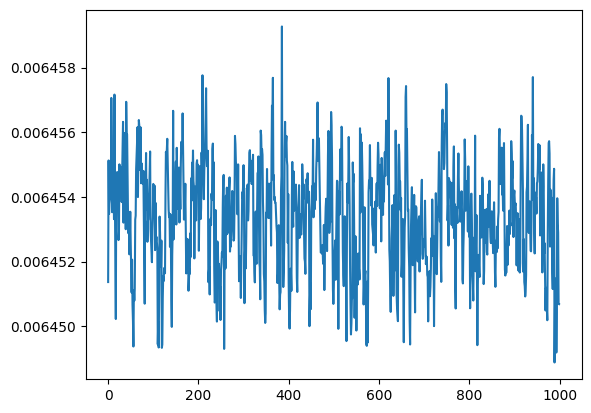

In [33]:
plt.plot(basis[40])

In [41]:
eigenvalues, eigenvectors = np.linalg.eig(np.cov(specs_test))
eigenvalues[0]

5.299182401799889e-08

In [43]:
v_0 = eigenvectors[:, 0]
np.dot(v_0, v_0)

0.9999999999999999

In [45]:
basis[0] / np.sqrt(eigenvalues[0])

array([-31747.39216647, -31747.46122606, -31747.55506282, -31747.59342239,
       -31747.64282995, -31747.68215582, -31747.72344656, -31747.77447156,
       -31747.82161352, -31747.89141369, -31747.92225934, -31747.96082184,
       -31747.9850452 , -31747.99671276, -31748.08313471, -31748.13063803,
       -31748.135116  , -31748.13614367, -31748.02903114, -31748.04460467,
       -31748.05053146, -31748.06093159, -31748.08096829, -31748.08758945,
       -31748.11034   , -31748.13123671, -31748.09611995, -31748.06755298,
       -31748.03394764, -31748.00575273, -31748.15679762, -31748.14609254,
       -31748.07318276, -31747.94234804, -31747.74102024, -31747.39744222,
       -31747.01144009, -31746.96553554, -31747.24250078, -31747.74962763,
       -31748.32436998, -31748.92518831, -31749.031667  , -31749.14397368,
       -31749.26470754, -31749.39900931, -31750.53463406, -31750.80094816,
       -31750.839006  , -31750.7225558 , -31750.07054855, -31750.02558317,
       -31749.84122753, -

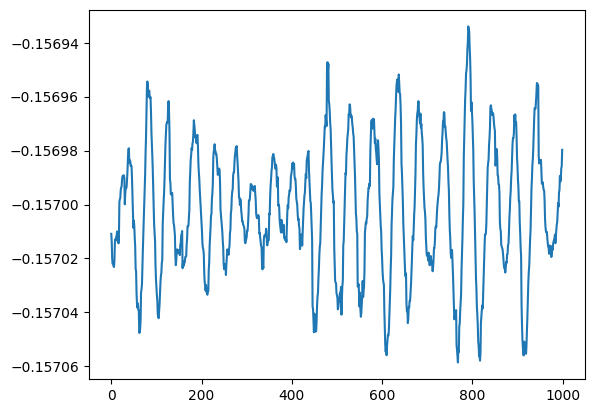

In [50]:
plt.plot(basis[2])

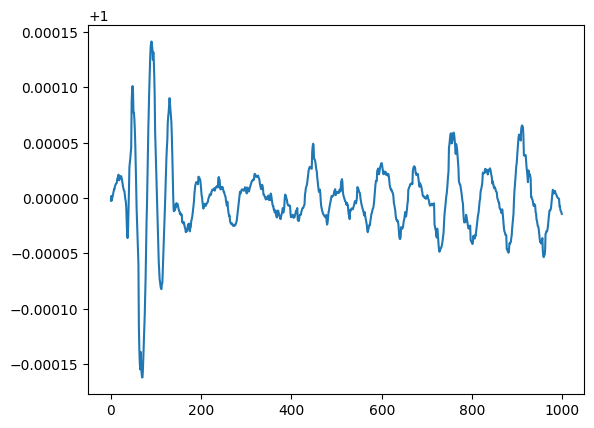

In [48]:
plt.plot(specs_test[0])

### Normalizing the basis vectors?

In [123]:
def klt(specs):
    '''
    Returns KL orthonormal basis for gain spectra.

    Inputs:
        specs: normalized gain spectral powers
    
    Returns:
        basis: Eigenspectra
    '''
    means = np.mean(specs, axis=1, keepdims=True)
    specs_standard = specs - means
    cov = np.cov(specs_standard)
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    basis = np.dot(eigenvectors.T, specs_standard)
    scales = np.linalg.norm(basis, axis=1, keepdims=True)
    powers = eigenvalues / np.sum(eigenvalues)
    return basis / scales, powers

In [124]:
bank_4_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_gains/decay/4'
specs = np.array([np.load(os.path.join(bank_4_dir, file))[1] for file in os.listdir(bank_4_dir)])
specs_test = specs[:, 4000:5000]

In [127]:
basis_norm, powers = klt(specs_test)

In [128]:
np.dot(basis_norm[0], basis_norm[0])

1.0

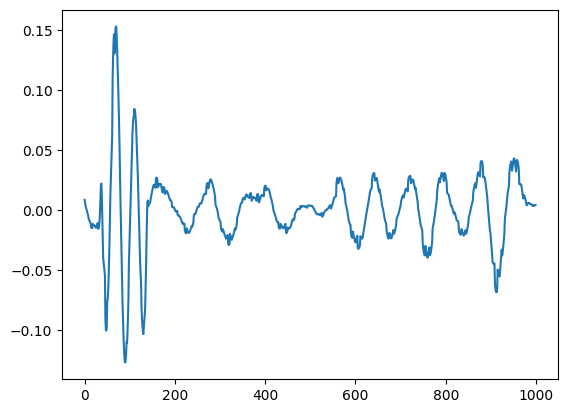

In [129]:
plt.plot(basis_norm[0])

In [130]:
powers 

array([9.17076495e-01, 1.32202043e-02, 1.03765353e-02, 6.97443641e-03,
       5.39496435e-03, 4.58119746e-03, 4.01591806e-03, 3.64146529e-03,
       3.38317954e-03, 3.20265480e-03, 2.86940745e-03, 2.39078399e-03,
       2.17624352e-03, 2.07010407e-03, 1.84543082e-03, 1.79086099e-03,
       1.46317072e-03, 1.18730578e-03, 1.08132506e-03, 1.00881756e-03,
       9.55360967e-04, 8.57832119e-04, 7.51714010e-04, 6.82237868e-04,
       6.22766460e-04, 5.37845527e-04, 5.02523031e-04, 4.74659709e-04,
       4.36235103e-04, 3.95736028e-04, 3.68238090e-04, 3.54728422e-04,
       3.01339561e-04, 2.83713700e-04, 2.51679668e-04, 2.45627494e-04,
       2.35755166e-04, 2.10212866e-04, 2.03593019e-04, 1.89308639e-04,
       4.68406378e-05, 1.56641571e-04, 1.46198891e-04, 1.36291884e-04,
       1.30240690e-04, 6.10400612e-05, 1.13473517e-04, 6.79128209e-05,
       7.25991027e-05, 7.90829786e-05, 8.42618141e-05, 1.04408634e-04,
       9.26099156e-05, 9.67899570e-05])

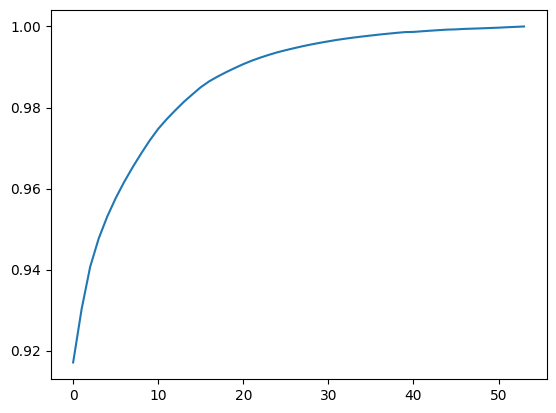

In [133]:
plt.plot(np.cumsum(powers))

### What if I don't rescale specs

In [134]:
def klt(specs):
    '''
    Returns KL orthonormal basis for gain spectra.

    Inputs:
        specs: normalized gain spectral powers
    
    Returns:
        basis: Eigenspectra
    '''
    cov = np.cov(specs)
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    basis = np.dot(eigenvectors.T, specs)
    scales = np.linalg.norm(basis, axis=1, keepdims=True)
    powers = eigenvalues / np.sum(eigenvalues)
    return basis / scales, powers

In [135]:
bank_4_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_gains/decay/4'
specs = np.array([np.load(os.path.join(bank_4_dir, file))[1] for file in os.listdir(bank_4_dir)])
specs_test = specs[:, 4000:5000]

In [136]:
basis_norm, powers = klt(specs_test)

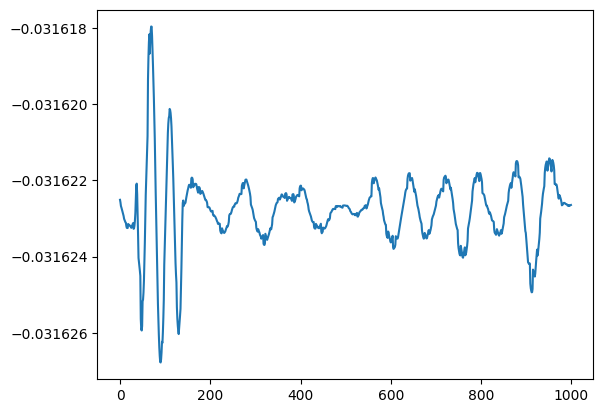

In [137]:
plt.plot(basis_norm[0])

In [138]:
powers

array([9.17076495e-01, 1.32202043e-02, 1.03765353e-02, 6.97443641e-03,
       5.39496435e-03, 4.58119746e-03, 4.01591806e-03, 3.64146529e-03,
       3.38317954e-03, 3.20265480e-03, 2.86940745e-03, 2.39078399e-03,
       2.17624352e-03, 2.07010407e-03, 1.84543082e-03, 1.79086099e-03,
       1.46317072e-03, 1.18730578e-03, 1.08132506e-03, 1.00881756e-03,
       9.55360967e-04, 8.57832119e-04, 7.51714010e-04, 6.82237868e-04,
       6.22766460e-04, 5.37845527e-04, 5.02523031e-04, 4.74659709e-04,
       4.36235103e-04, 3.95736028e-04, 3.68238090e-04, 3.54728422e-04,
       3.01339561e-04, 2.83713700e-04, 2.51679668e-04, 2.45627494e-04,
       2.35755166e-04, 2.10212866e-04, 2.03593019e-04, 1.89308639e-04,
       4.68406378e-05, 1.56641571e-04, 1.46198891e-04, 1.36291884e-04,
       1.30240690e-04, 6.10400612e-05, 1.13473517e-04, 6.79128209e-05,
       7.25991027e-05, 7.90829786e-05, 8.42618141e-05, 1.04408634e-04,
       9.26099156e-05, 9.67899570e-05])

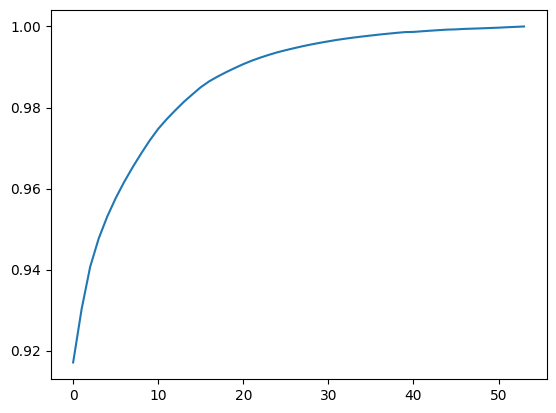

In [139]:
plt.plot(np.cumsum(powers))

In [144]:
np.dot(basis_norm[0], basis_norm[3])

-0.9999999989462824

The eigenspectra are morphologically the same, but they're not orthogonal. So let's not do it...

## v. Target spectrum test

In [2]:
def klt(specs):
    '''
    Returns KL orthonormal basis for gain spectra.

    Inputs:
        specs: normalized gain spectral powers
    
    Returns:
        basis: Eigenspectra
    '''
    means = np.mean(specs, axis=1, keepdims=True)
    specs_standard = specs - means
    cov = np.cov(specs_standard)
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    basis = np.dot(eigenvectors.T, specs_standard)
    scales = np.linalg.norm(basis, axis=1, keepdims=True)
    powers = eigenvalues / np.sum(eigenvalues)
    return basis / scales, powers

In [3]:
bank_4_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_gains/decay/4'
specs = np.array([np.load(os.path.join(bank_4_dir, file))[1] for file in os.listdir(bank_4_dir)])
specs_test = specs[:, 4000:5000]
basis_norm, powers = klt(specs_test)

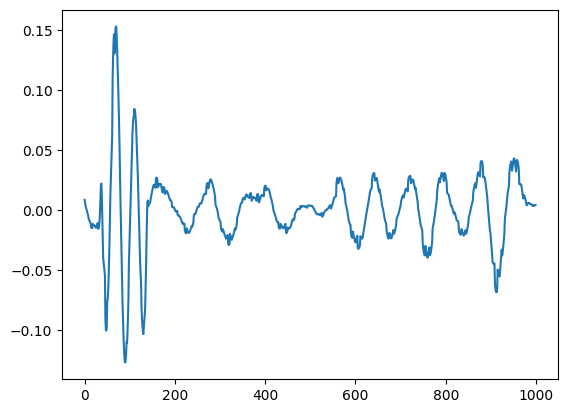

In [4]:
# Sanity check
plt.plot(basis_norm[0])

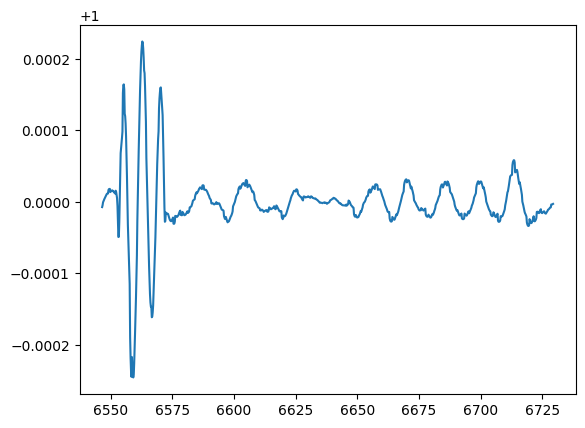

In [5]:
# Test
targ_spec = np.load('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized/decay/4/57999_19361.npy')
plt.plot(*targ_spec[:, 4000:5000])

### 5 modes

In [6]:
targ_spec_test = targ_spec[1, 4000:5000] - np.nanmean(targ_spec[1, 4000:5000])
# First 5 modes
coeffs = np.dot(basis_norm[:5], targ_spec_test)
coeffs

array([-1.40366919e-03, -2.84627556e-05,  1.79893662e-04, -2.11368833e-04,
       -7.73549094e-05])

In [7]:
basis_norm[:5]

array([[ 0.00852058,  0.00633563,  0.00336676, ...,  0.00391068,
         0.0040693 ,  0.00421418],
       [ 0.0275097 ,  0.02624635,  0.01492226, ...,  0.00618201,
         0.00762571,  0.00859432],
       [-0.0112965 , -0.014907  , -0.02316355, ...,  0.02015853,
         0.02098276,  0.02894323],
       [-0.00688373, -0.00607433, -0.00017452, ..., -0.01049978,
        -0.01325134, -0.01213503],
       [-0.01079133, -0.00548509, -0.01012574, ..., -0.03674845,
        -0.04058498, -0.04215979]])

In [8]:
basis_norm[:5] * coeffs[:, np.newaxis]

array([[-1.19600701e-05, -8.89312493e-06, -4.72582239e-06, ...,
        -5.48929852e-06, -5.71195159e-06, -5.91532163e-06],
       [-7.83001793e-07, -7.47043340e-07, -4.24728654e-07, ...,
        -1.75957060e-07, -2.17048627e-07, -2.44618037e-07],
       [-2.03216881e-06, -2.68167476e-06, -4.16697672e-06, ...,
         3.62639175e-06,  3.77466528e-06,  5.20670294e-06],
       [ 1.45500560e-06,  1.28392479e-06,  3.68886199e-08, ...,
         2.21932673e-06,  2.80091960e-06,  2.56496812e-06],
       [ 8.34762514e-07,  4.24298343e-07,  7.83275566e-07, ...,
         2.84267320e-06,  3.13944746e-06,  3.26126653e-06]])

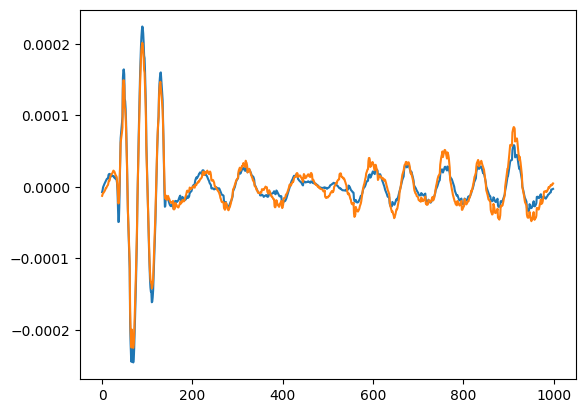

In [9]:
est = np.sum(basis_norm[:5] * coeffs[:, np.newaxis], axis=0)
plt.plot(targ_spec_test)
plt.plot(est)

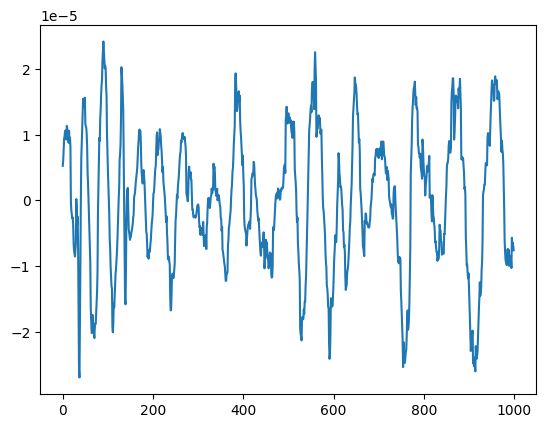

In [10]:
plt.plot(targ_spec_test-est)

### 10 modes

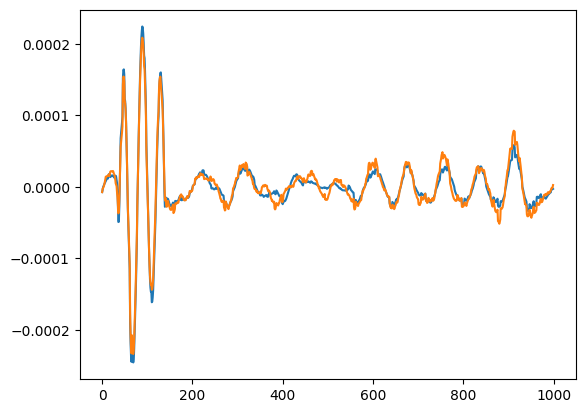

In [11]:
coeffs = np.dot(basis_norm[:10], targ_spec_test)
est = np.sum(basis_norm[:10] * coeffs[:, np.newaxis], axis=0)
plt.plot(targ_spec_test)
plt.plot(est)

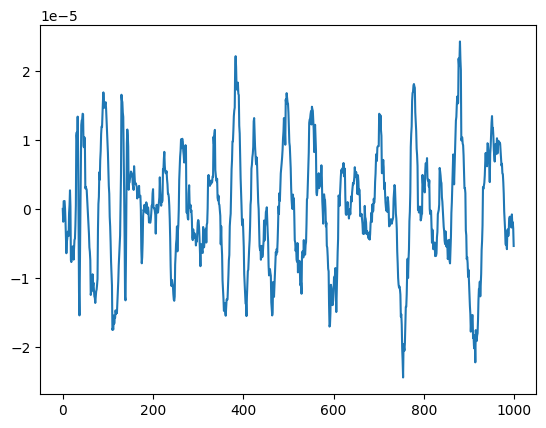

In [12]:
plt.plot(targ_spec_test-est)

In [13]:
np.std(targ_spec_test), np.std(targ_spec_test-est)

(4.648725292018233e-05, 8.470834719046697e-06)

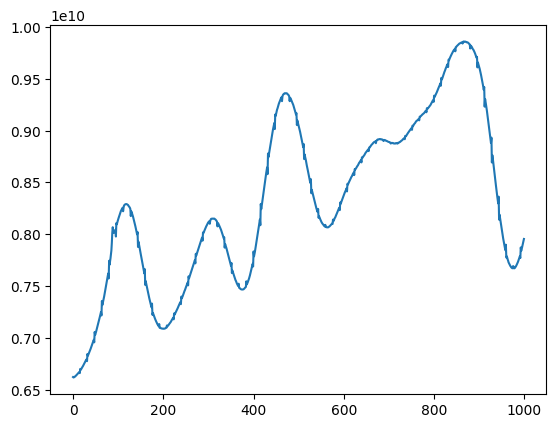

In [14]:
plt.plot(np.load('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed/4/57999_19361.npy')[1, 4000:5000])

Hmm, maybe need to recliff correct

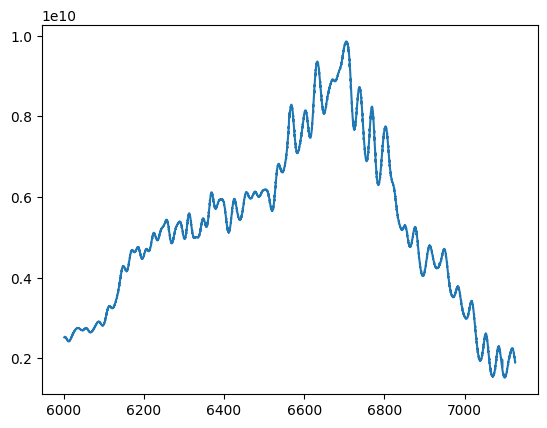

In [15]:
plt.plot(*np.load('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed/4/57999_19361.npy'))

## vi. Asymmetry test (4000-5000, no quality cut, 5 modes)

In [66]:
info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/all_lscx_info.csv', sep='\t')
norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized/decay/4'
info_trimmed = info[info['time'].apply(lambda l: l+'.npy').isin(os.listdir(norm_dir))]
spectra = np.array([np.load(os.path.join(norm_dir, file+'.npy'))[1, 4000:5000] for file in info_trimmed['time']])
spectra

array([[1.00003346, 1.00003426, 1.00002835, ..., 1.00000566, 1.00000525,
        1.00000486],
       [1.00003294, 1.00003333, 1.00002802, ..., 1.00000159, 1.00000171,
        1.00000165],
       [1.00003435, 1.00003467, 1.00002878, ..., 1.00000647, 1.00000602,
        1.00000607],
       ...,
       [0.99999927, 1.00000183, 1.00000574, ..., 0.99999456, 0.99999467,
        0.99999401],
       [0.99999771, 1.00000045, 1.00000417, ..., 0.99999593, 0.99999598,
        0.99999569],
       [0.99999361, 0.99999474, 1.00000081, ..., 0.99999388, 0.99999296,
        0.99999269]])

In [67]:
np.sum(np.any(np.isnan(spectra), axis=1))

37

In [68]:
nan_mask = np.all(np.isfinite(spectra), axis=1)
spectra = spectra[nan_mask]
info_trimmed = info_trimmed[nan_mask]

In [69]:
len(spectra)

13476

In [70]:
# Simple intensity asymmetry (all targets)
def build_asymmetry(specs, info):
    inner = specs[info['phi'] < 90]
    outer = specs[info['phi'] > 90]

    inner_mean = np.mean(inner, axis=0)
    outer_mean = np.mean(outer, axis=0)

    return inner_mean - outer_mean

In [71]:
asym = build_asymmetry(spectra, info_trimmed)
asym

array([-4.43481341e-07, -2.63319506e-07, -2.41112585e-07, -3.18597713e-07,
       -3.46810557e-07, -1.82701873e-07, -2.39130209e-08,  7.87964471e-09,
        1.98884390e-07,  5.70670796e-07,  7.07660930e-07,  8.31965516e-07,
        1.11132033e-06,  1.36998152e-06,  1.82667903e-06,  1.86165812e-06,
        1.91126497e-06,  1.99138120e-06,  1.68420095e-06,  1.47238926e-06,
        1.27169389e-06,  1.24463221e-06,  1.21598577e-06,  9.56848245e-07,
        8.42293552e-07,  8.89881978e-07,  7.01954803e-07,  5.18207880e-07,
        5.25650540e-07,  5.57670735e-07,  6.06547453e-07,  3.56362808e-07,
        1.55179318e-07, -3.41353132e-08, -6.40023491e-07, -5.21817717e-06,
       -8.89262492e-06, -6.39547834e-06, -3.42579281e-06, -5.24728014e-07,
        2.07542544e-06,  4.35121280e-06,  5.10173416e-06,  5.90197068e-06,
        6.90084960e-06,  7.91460285e-06,  3.99407524e-06,  3.23080415e-06,
        3.08281837e-06,  3.13360928e-06,  2.89220325e-06,  2.80347872e-06,
        2.72972298e-06,  

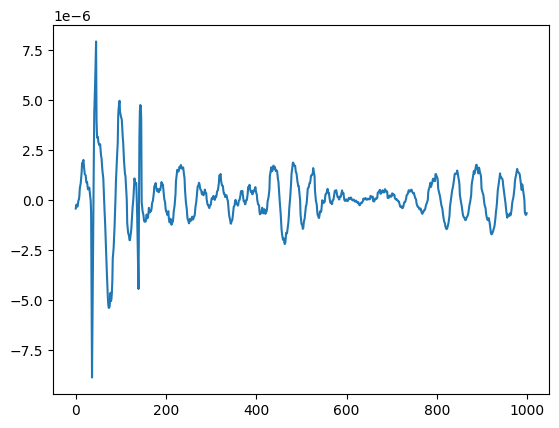

In [72]:
plt.plot(asym)

In [73]:
def kl_correct(specs, basis, n_modes=5):
    new_specs = np.zeros_like(specs)
    for i, spec in enumerate(specs):
        spec_norm = spec - np.nanmean(spec)
        coeffs = np.dot(basis[:n_modes], spec_norm)
        est = np.sum(basis[:n_modes] * coeffs[:, np.newaxis], axis=0)
        new_specs[i] = spec_norm - est
    return new_specs

In [74]:
def klt(specs):
    '''
    Returns KL orthonormal basis for gain spectra.

    Inputs:
        specs: normalized gain spectral powers
    
    Returns:
        basis: Eigenspectra
    '''
    means = np.mean(specs, axis=1, keepdims=True)
    specs_standard = specs - means
    cov = np.cov(specs_standard)
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    basis = np.dot(eigenvectors.T, specs_standard)
    scales = np.linalg.norm(basis, axis=1, keepdims=True)
    powers = eigenvalues / np.sum(eigenvalues)
    return basis / scales, powers

bank_4_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_gains/decay/4'
specs = np.array([np.load(os.path.join(bank_4_dir, file))[1] for file in os.listdir(bank_4_dir)])
specs_test = specs[:, 4000:5000]
basis_norm, powers = klt(specs_test)

In [75]:
kl_spectra = kl_correct(spectra, basis_norm, n_modes=10)
kl_spectra

array([[ 3.40984530e-05,  3.07040902e-05,  2.40072698e-05, ...,
         9.71578227e-07, -1.31884806e-06, -3.25520740e-06],
       [ 3.33886544e-05,  2.94587469e-05,  2.32541315e-05, ...,
        -2.66520045e-06, -4.53532007e-06, -6.23407103e-06],
       [ 3.45847341e-05,  3.06168279e-05,  2.39778496e-05, ...,
         1.92168878e-06, -5.50874902e-07, -2.08415755e-06],
       ...,
       [ 6.63351196e-06,  6.85994566e-06,  3.45975020e-06, ...,
         1.83237506e-06,  2.15470601e-06,  2.19725336e-06],
       [ 7.11858204e-06,  7.69800678e-06,  4.80271652e-06, ...,
         9.36814071e-07,  1.23534806e-06,  1.30372538e-06],
       [ 3.69342623e-06,  2.93813366e-06,  2.19253579e-06, ...,
        -1.26170255e-06, -1.91846996e-06, -1.51396330e-06]])

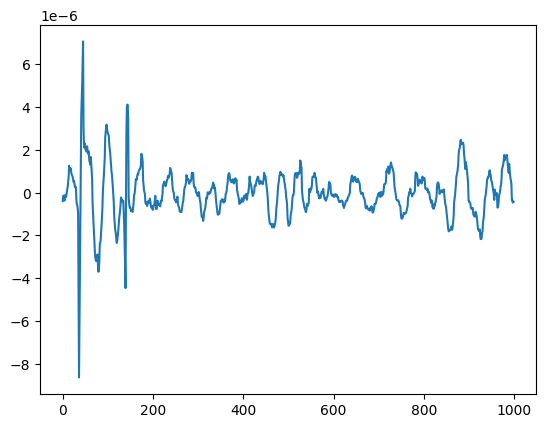

In [76]:
kl_asym = build_asymmetry(kl_spectra, info_trimmed)
plt.plot(kl_asym)

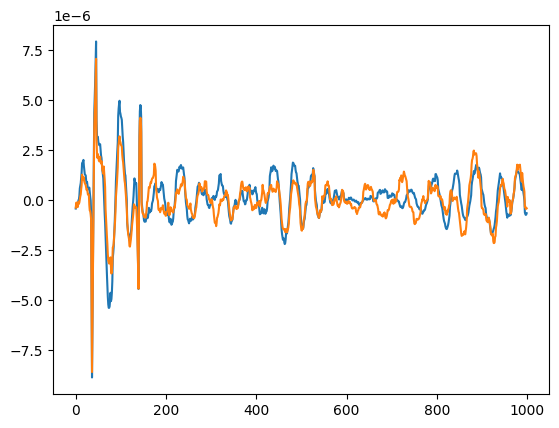

In [77]:
plt.plot(asym)
plt.plot(kl_asym)

In [78]:
scipy.stats.median_abs_deviation(asym)

5.692851682281841e-07

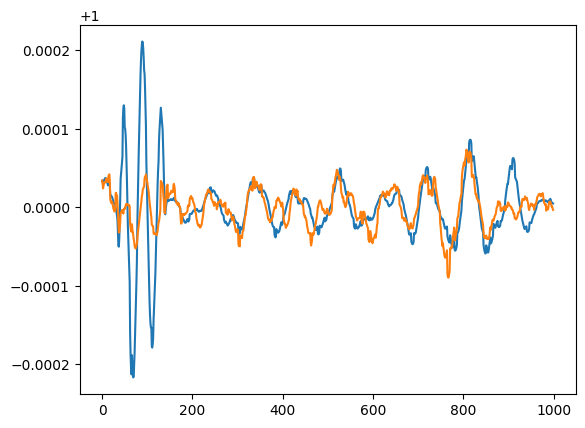

In [47]:
plt.plot(spectra[0])
plt.plot(kl_spectra[0]+1)

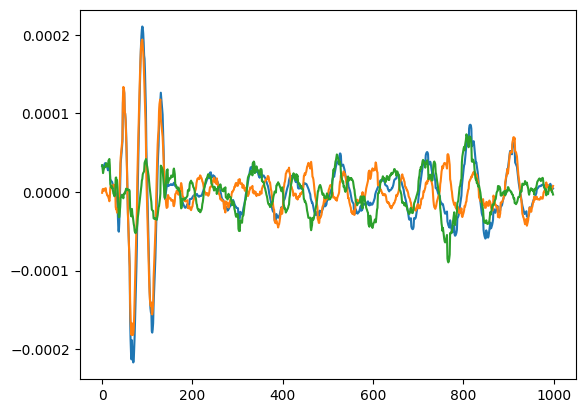

In [52]:
spec = spectra[0]
spec_norm = spec - np.nanmean(spec)
coeffs = np.dot(basis_norm[:10], spec_norm)
est = np.sum(basis_norm[:10] * coeffs[:, np.newaxis], axis=0)
plt.plot(spec_norm)
plt.plot(est)
plt.plot(spec_norm-est)

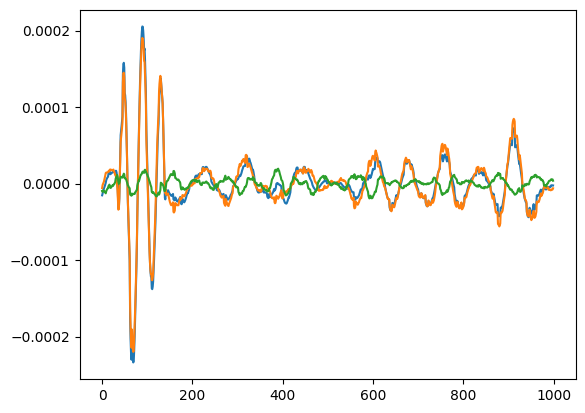

In [55]:
spec = spectra[6000]
spec_norm = spec - np.nanmean(spec)
coeffs = np.dot(basis_norm[:10], spec_norm)
est = np.sum(basis_norm[:10] * coeffs[:, np.newaxis], axis=0)
plt.plot(spec_norm)
plt.plot(est)
plt.plot(spec_norm-est)

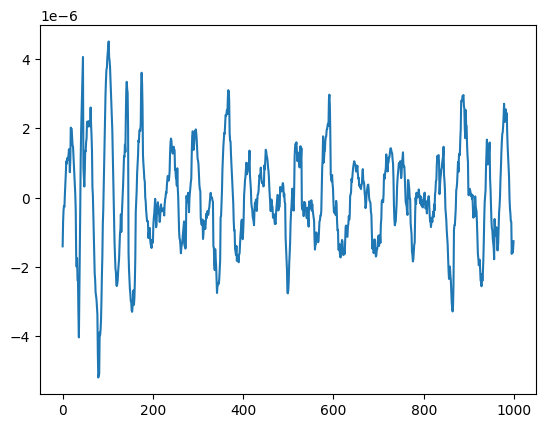

In [58]:
kl_asym_trunc = build_asymmetry(kl_spectra[6000:], info_trimmed[6000:])
plt.plot(kl_asym_trunc)

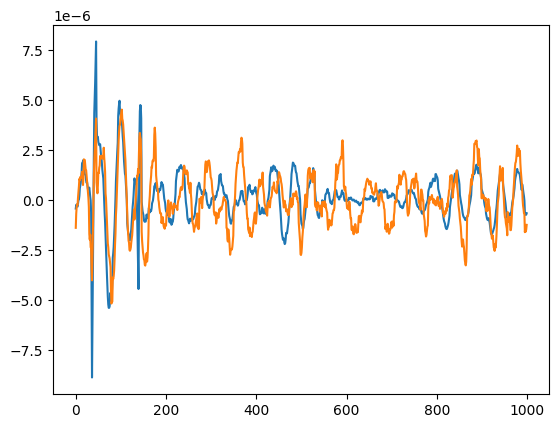

In [59]:
plt.plot(asym)
plt.plot(kl_asym_trunc)

## vii. Asymmetry test (w/ cut)

In [60]:
info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/all_lscx_info.csv', sep='\t')
norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_cut/decay/4'
info_trimmed = info[info['time'].apply(lambda l: l+'.npy').isin(os.listdir(norm_dir))]
spectra = np.array([np.load(os.path.join(norm_dir, file+'.npy'))[1, 4000:5000] for file in info_trimmed['time']])
nan_mask = np.all(np.isfinite(spectra), axis=1)
spectra = spectra[nan_mask]
info_trimmed = info_trimmed[nan_mask]

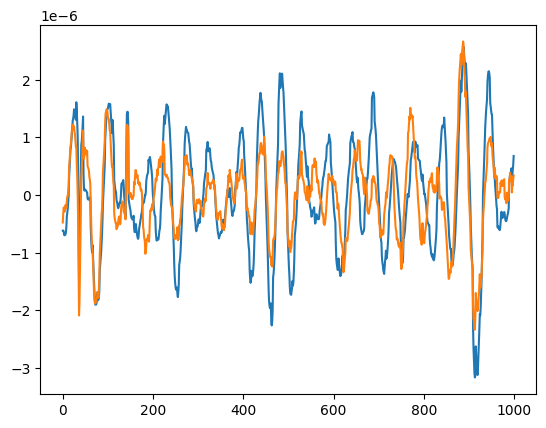

In [62]:
asym = build_asymmetry(spectra, info_trimmed)
kl_spectra = kl_correct(spectra, basis_norm, n_modes=10)
kl_asym = build_asymmetry(kl_spectra, info_trimmed)
plt.plot(asym)
plt.plot(kl_asym)

In [65]:
len(spectra)

1502

## viii. Examining decomposition of normalized gains

In [80]:
norm_gain_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_gains/decay/4'
norm_gains = np.array([np.load(os.path.join(norm_gain_dir, file))[1, 4000:5000] for file in os.listdir(norm_gain_dir)])
norm_gains

array([[0.99999778, 1.00000191, 0.99999784, ..., 0.9999882 , 0.99998714,
        0.99998575],
       [0.99999029, 0.9999908 , 0.99999175, ..., 0.99999462, 0.99999418,
        0.9999929 ],
       [0.99999197, 0.99999355, 0.99999144, ..., 0.99999501, 0.99999501,
        0.99999585],
       ...,
       [0.99998009, 0.99997578, 0.99999368, ..., 1.00000051, 0.99999764,
        0.99999791],
       [0.99997598, 0.9999768 , 0.99997425, ..., 1.00000989, 1.00000867,
        1.00000866],
       [1.00000338, 1.00000471, 1.00000638, ..., 0.99999061, 0.99998711,
        0.99998388]])

In [81]:
np.any(np.isnan(norm_gains))

False

In [ ]:
kl_norm_gains = kl_correct(norm_gains, basis_norm)

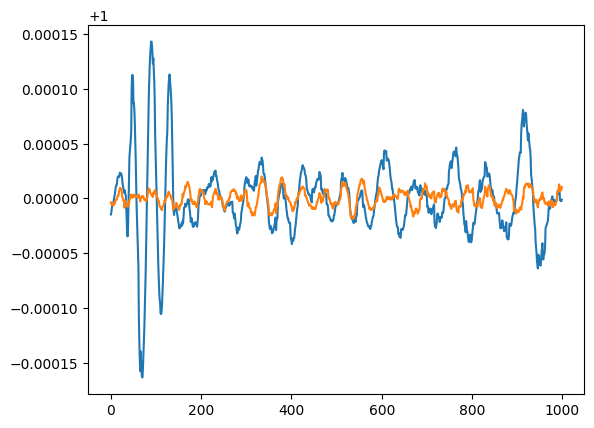

In [90]:
plt.plot(norm_gains[30])
plt.plot(kl_norm_gains[30]+1)

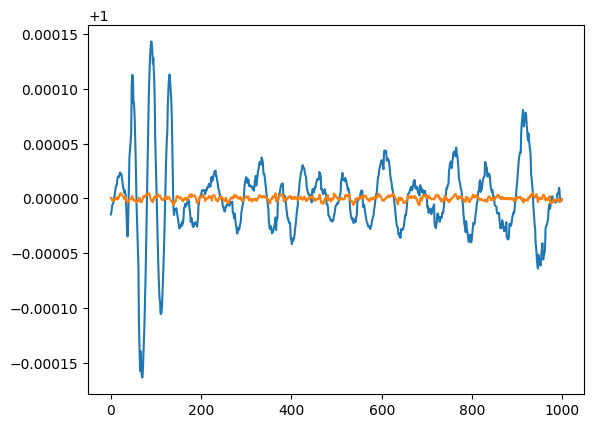

In [97]:
kl_norm_gains = kl_correct(norm_gains, basis_norm, n_modes=30)
plt.plot(norm_gains[30])
plt.plot(kl_norm_gains[30]+1)

## ix. One more try, with higher number of modes... (no cut)

In [98]:
info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/all_lscx_info.csv', sep='\t')
norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized/decay/4'
info_trimmed = info[info['time'].apply(lambda l: l+'.npy').isin(os.listdir(norm_dir))]
spectra = np.array([np.load(os.path.join(norm_dir, file+'.npy'))[1, 4000:5000] for file in info_trimmed['time']])
nan_mask = np.all(np.isfinite(spectra), axis=1)
spectra = spectra[nan_mask]
info_trimmed = info_trimmed[nan_mask]

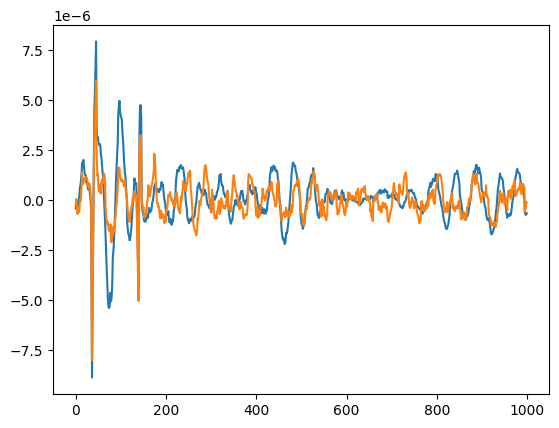

In [103]:
asym = build_asymmetry(spectra, info_trimmed)
kl_spectra = kl_correct(spectra, basis_norm, n_modes=30)
kl_asym = build_asymmetry(kl_spectra, info_trimmed)
plt.plot(asym)
plt.plot(kl_asym)

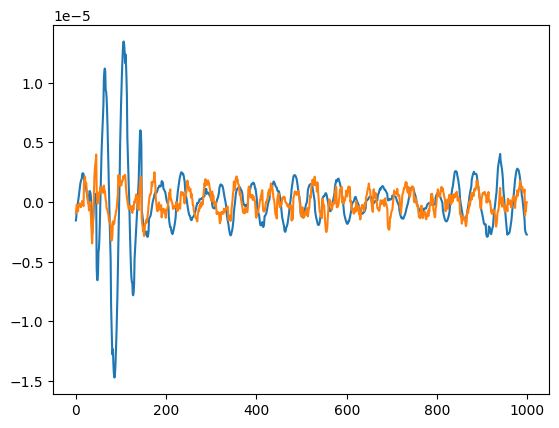

In [102]:
asym = build_asymmetry(spectra[6000:], info_trimmed[6000:])
kl_spectra = kl_correct(spectra, basis_norm, n_modes=30)
kl_asym = build_asymmetry(kl_spectra[6000:], info_trimmed[6000:])
plt.plot(asym)
plt.plot(kl_asym)

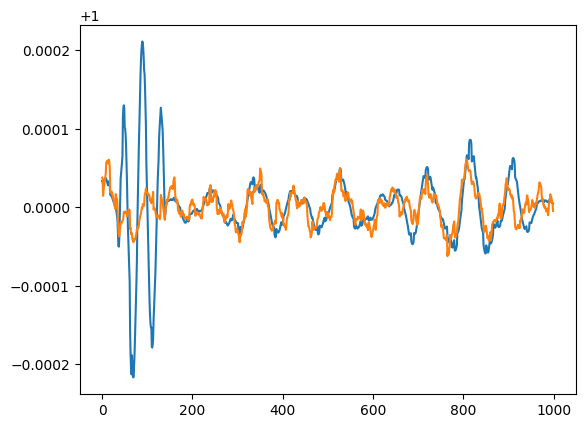

In [104]:
plt.plot(spectra[0])
plt.plot(kl_spectra[0]+1)

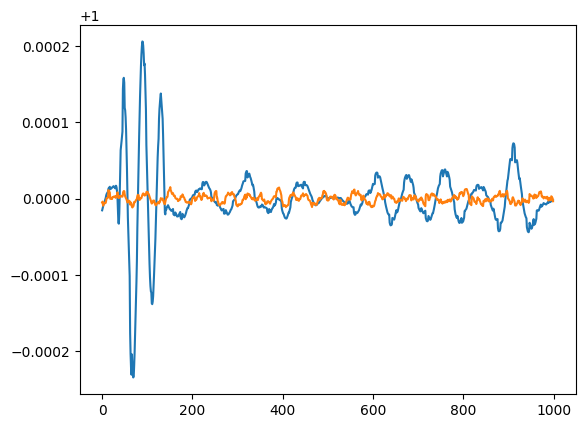

In [101]:
plt.plot(spectra[6000])
plt.plot(kl_spectra[6000]+1)

In [107]:
times = info_trimmed['time'].tolist()
times[0], times[6000]

('57950_74488', '58454_28134')

In [108]:
info_trimmed['epoch'].tolist()[6000]

'AGBT18B_999_73'

## EIGENSPECTRA EXAMPLE PLOT (for Karl)

In [61]:
def klt(specs):
    '''
    Returns KL orthonormal basis for gain spectra.

    Inputs:
        specs: normalized gain spectral powers
    
    Returns:
        basis: Eigenspectra
    '''
    means = np.mean(specs, axis=1, keepdims=True)
    specs_standard = specs - means
    cov = np.cov(specs_standard)
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    basis = np.dot(eigenvectors.T, specs_standard)
    scales = np.linalg.norm(basis, axis=1, keepdims=True)
    powers = eigenvalues / np.sum(eigenvalues)
    return basis / scales, powers

bank_4_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_gains_u/decay/4'
specs = np.array([np.load(os.path.join(bank_4_dir, file))[1] for file in os.listdir(bank_4_dir)])
specs_test = specs[:, 4000:5000]
basis_norm, powers = klt(specs_test)

In [62]:
xs = np.load(os.path.join(bank_4_dir, os.listdir(bank_4_dir)[0]))[0,4000:5000]
xs

array([6546.479702  , 6546.66280746, 6546.84591293, 6547.0290184 ,
       6547.21212387, 6547.39522934, 6547.57833481, 6547.76144028,
       6547.94454575, 6548.12765121, 6548.31075668, 6548.49386215,
       6548.67696762, 6548.86007309, 6549.04317856, 6549.22628403,
       6549.4093895 , 6549.59249496, 6549.77560043, 6549.9587059 ,
       6550.14181137, 6550.32491684, 6550.50802231, 6550.69112778,
       6550.87423325, 6551.05733871, 6551.24044418, 6551.42354965,
       6551.60665512, 6551.78976059, 6551.97286606, 6552.15597153,
       6552.339077  , 6552.52218246, 6552.70528793, 6552.8883934 ,
       6553.07149887, 6553.25460434, 6553.43770981, 6553.62081528,
       6553.80392075, 6553.98702621, 6554.17013168, 6554.35323715,
       6554.53634262, 6554.71944809, 6554.90255356, 6555.08565903,
       6555.2687645 , 6555.45186996, 6555.63497543, 6555.8180809 ,
       6556.00118637, 6556.18429184, 6556.36739731, 6556.55050278,
       6556.73360825, 6556.91671371, 6557.09981918, 6557.28292

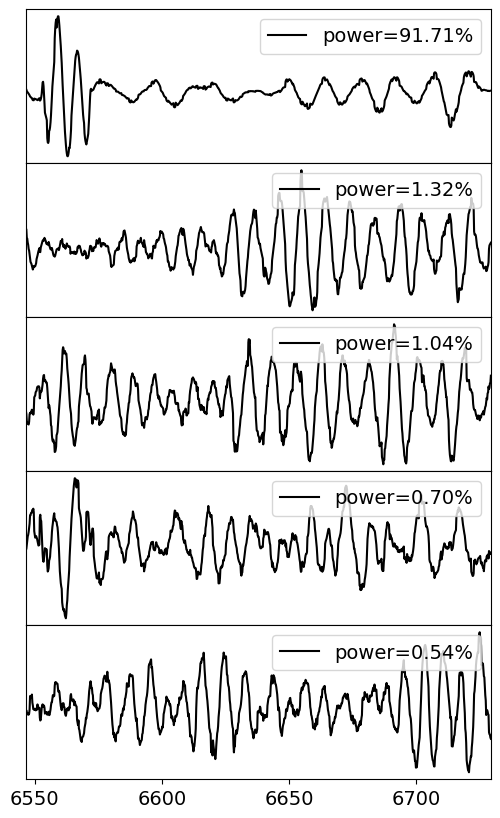

In [ ]:
fig, axs = plt.subplots(5, 1, figsize=(6, 10), sharex=True)
fig.subplots_adjust(hspace=0)

for i, ax in enumerate(axs):
    ax.plot(xs, basis_norm[i], c='k', label=f'power={powers[i]:.2%}')
    ax.set_xlim(xs[0], xs[-1])
    ax.set_yticks([])
    ax.legend(loc='upper right')

# **V. Proper Treatment of Node Cliffs and Gaps**

## i. New cliff correction (no condition on cliff size)

In [110]:
def cliff_correct(ys):
    '''Eliminate power discontinuities between data blocks.'''
    n_nodes = len(ys) // 1024
    reshaped = np.reshape(ys, (n_nodes, 1024)).copy()

    for i in range(n_nodes-1):
        left = reshaped[i]
        right = reshaped[i+1]
        diff = np.abs(right[0] - left[-1])
        avg = (np.abs(right[1] - right[0]) + np.abs(left[-1] - left[-2])) / 2
        
        # Fit polynomial to middle 12 points of coarse channel
        p = Polynomial.fit(np.arange(12), left[-14:-2], 1) #linear
        y_fit = p(16)
        a = y_fit / right[2]
        for j in range(i+1, n_nodes):
            reshaped[j] *= a
    
    out = np.concatenate(reshaped)
    return out

def correct(file, bank_dir=None, save_dir=None):
    xs, ys = np.load(os.path.join(bank_dir, file))
    cliffed = cliff_correct(ys)
    new_data = np.array([xs, cliffed])
    np.save(os.path.join(save_dir, file), new_data)

data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed'
save_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed_corrected'

for bank in range(10):
    bank_data_dir = os.path.join(data_dir, str(bank))
    bank_save_dir = os.path.join(save_dir, str(bank))
    os.makedirs(bank_save_dir, exist_ok=True)
    with Pool(processes=10) as p:
        correct_partial = partial(correct, bank_dir=bank_data_dir, save_dir=bank_save_dir)
        _ = list(tqdm(p.imap_unordered(correct_partial, os.listdir(bank_data_dir)), total=len(os.listdir(bank_data_dir))))

  0%|          | 0/14175 [00:00<?, ?it/s]

  0%|          | 0/13750 [00:00<?, ?it/s]

  0%|          | 0/13403 [00:00<?, ?it/s]

  0%|          | 0/13564 [00:00<?, ?it/s]

  0%|          | 0/13513 [00:00<?, ?it/s]

  0%|          | 0/13395 [00:00<?, ?it/s]

  0%|          | 0/14521 [00:00<?, ?it/s]

  0%|          | 0/14524 [00:00<?, ?it/s]

  0%|          | 0/14490 [00:00<?, ?it/s]

  0%|          | 0/1855 [00:00<?, ?it/s]

## ii. New heatmaps

In [2]:
plt.rcParams['font.size'] = 14

def plot_heatmap(info, xs, all_spectra, case, bank, start_freq=8000, width=100, n_bins=50, time=False, resid=False, cut=True):
    mask = (xs >= start_freq) & (xs < start_freq + width)
    nans = np.full(xs.shape, np.nan)[mask]
    end_freq = xs[mask][-1]

    info['time_mjd'] = info['time'].apply(lambda mjd: int(mjd.split('_')[0])) #[int(mjd.split('_')[0]) for mjd in info['time']]
    info['cos_theta'] = info['theta'].apply(lambda theta: math.cos(math.radians(theta))) #[math.cos(math.radians(theta)) for theta in info['theta']]
    info['cos_phi'] = info['phi'].apply(lambda phi: math.cos(math.radians(phi))) #[math.cos(math.radians(phi)) for phi in info['phi']]

    var_list = ['time_mjd'] if time else ['cos_theta', 'cos_phi']

    fig = plt.figure(figsize=(12, 6), layout="tight")
    gs = fig.add_gridspec(len(var_list), 2, wspace=0, hspace=0.2, width_ratios=[3, 1])
    axs = gs.subplots().flat

    def create_map(bin_column):
        for i in range(n_bins):
            bin_mask = (info[bin_column] == i).to_numpy()
            spectra = all_spectra[bin_mask][:, mask]
            if spectra.size:
                avg = np.nanmean(spectra, axis=0)
                yield avg
            else:
                yield nans

    for i, var in enumerate(var_list):
        bounds = (min(info['time_mjd']), max(info['time_mjd'])) if var == 'time_mjd' else (-1, 1)
        bins = np.linspace(*bounds, n_bins+1)
        info[f'{var}_bin'] = pd.cut(info[var], bins, labels=False)
            
        heat_map = np.array(list(create_map(f'{var}_bin')))
        if resid:
            heat_map = heat_map - np.nanmean(all_spectra[:, mask], axis=0)

        ax = axs[2*i]
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(np.array(heat_map))
        if resid is not None:
            vmax = max(vmax, -vmin)
            ndigits = -int(math.floor(math.log10(vmax))) + 1
            vmax = round(vmax, ndigits)
            vmin = -vmax
        else:
            vmax = max(vmax, 2-vmin)
            ndigits = -int(math.floor(math.log10(vmax - 1))) + 1
            vmax = round(vmax, ndigits)
            vmin = 2 - vmax
        norm = Normalize(vmin=vmin, vmax=vmax)
        extent = [np.min(xs[mask]), np.max(xs[mask]), *bounds]

        #im0 = axs[0].imshow(theta_map, extent=extent, origin='lower', norm=norm, aspect='auto')
        im1 = ax.imshow(heat_map, extent=extent, cmap='RdBu' if resid is not None else 'viridis', origin='lower', norm=norm, aspect='auto', interpolation='none')
        
        #axs[0].set_ylabel(r'$\mathrm{cos}({\theta})$', fontsize=18)
        if var == 'cos_phi':
            label = r'$\mathrm{cos}({\phi})$'
        elif var == 'cos_theta':
            label = r'$\mathrm{cos}({\theta})$'
        else:
            label = 'Modified JD'

        ax.set_ylabel(label, fontsize=18)
        # for i in bins:
        #     ax.axhline(i, c='r')

        hist_ax = axs[2*i+1]
        nan_mask = np.any(np.isfinite(all_spectra[:, mask]), axis=1)
        info_mask = info[nan_mask]
        hist_ax.hist(info_mask[var], bins=bins, facecolor='lightgray', edgecolor='k', orientation='horizontal')
        hist_ax.set_yticks([])
        hist_ax.set_ylim(*bounds)

        if var != 'time_mjd':
            ax.axhline(0, c='r') # Inward/outward division
            hist_ax.axhline(0, c='r') # Inward/outward division
            ax.set_yticks(np.linspace(-1, 1, 5))
    
    case_str = f'{case} cut' if cut else case
    fig.suptitle(f'Bank {bank} {case_str}: {start_freq:.0f}-{end_freq:.0f} MHz', fontsize=20)
    #ax.set_aspect('auto')

    axs[2*(len(var_list)-1)].set_xlabel(r'$\nu$ [MHz]', fontsize=18)
    axs[2*(len(var_list)-1)+1].set_xlabel('Counts', fontsize=18)

    cax = inset_axes(
        hist_ax,
        width="15%",
        height=f"{100 * len(var_list) + 20 * (len(var_list)-1)}%",
        loc="lower left",
        bbox_to_anchor=(1.05, 0., 1, 1),
        bbox_transform=hist_ax.transAxes,
        borderpad=0
    )
    cbar = fig.colorbar(im1, cax=cax, orientation='vertical')
    cbar.set_label('Normalized Power Residual' if resid is not None else 'Normalized Power', fontsize=18)
    
    return fig

In [3]:
norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized'
norm_cut_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_cut'

info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/all_lscx_info.csv'
info = pd.read_csv(info_dir, sep='\t')

cases = ['decay', 'ann']
banks = np.arange(10)

width = 187.5/2

date = '082426'

os.makedirs(f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/theta_phi', exist_ok=True)

def round_up_to_nearest_10(number):
    return math.ceil(number / 10) * 10

for case in cases:
    is_decay = case == 'decay'
    for cut in [True, False]:
        if cut:
            pdf_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/theta_phi/{case}_cut.pdf'
            data_dir = norm_cut_dir
        else:
            pdf_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/theta_phi/{case}.pdf'
            data_dir = norm_dir
        pdf = PdfPages(pdf_dir)
        
        for bank in banks:
            bank_dir = os.path.join(data_dir, case, str(bank))
            bank_info = info[info['time'].apply(lambda l: l+'.npy').isin(os.listdir(bank_dir))]
            
            xs = np.load(os.path.join(bank_dir, bank_info['time'].tolist()[0]+'.npy'))[0]
            all_spectra = np.array([
                np.load(os.path.join(bank_dir, file+'.npy'))[1]
                for file in bank_info['time']
            ])
            
            start_freqs = np.arange(xs[0], xs[-1], width)

            for start_freq in tqdm(start_freqs, desc=f'Bank {bank} {case} cut' if cut else f'Bank {bank} {case}'):
                fig = plot_heatmap(
                    bank_info,
                    xs,
                    all_spectra,
                    case,
                    bank,
                    start_freq=start_freq,
                    width=width,
                    resid=True,
                    cut=cut
                )
                pdf.savefig(fig, bbox_inches='tight', dpi=72)
                plt.close(fig)

        pdf.close()

Bank 0 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 1 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 2 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 3 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 4 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

...

Bank 5 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 6 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 7 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 8 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 9 ann:   0%|          | 0/16 [00:00<?, ?it/s]

In [4]:
norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized'
norm_cut_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_cut'

info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/all_lscx_info.csv'
info = pd.read_csv(info_dir, sep='\t')

cases = ['decay', 'ann']
banks = np.arange(10)

width = 187.5/2

date = '082426'

os.makedirs(f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/time', exist_ok=True)

def round_up_to_nearest_10(number):
    return math.ceil(number / 10) * 10

for case in cases:
    is_decay = case == 'decay'
    for cut in [True, False]:
        if cut:
            pdf_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/time/{case}_cut.pdf'
            data_dir = norm_cut_dir
        else:
            pdf_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/time/{case}.pdf'
            data_dir = norm_dir
        pdf = PdfPages(pdf_dir)
        
        for bank in banks:
            bank_dir = os.path.join(data_dir, case, str(bank))
            bank_info = info[info['time'].apply(lambda l: l+'.npy').isin(os.listdir(bank_dir))]
            
            xs = np.load(os.path.join(bank_dir, bank_info['time'].tolist()[0]+'.npy'))[0]
            all_spectra = np.array([
                np.load(os.path.join(bank_dir, file+'.npy'))[1]
                for file in bank_info['time']
            ])
            
            start_freqs = np.arange(xs[0], xs[-1], width)

            for start_freq in tqdm(start_freqs, desc=f'Bank {bank} {case} cut' if cut else f'Bank {bank} {case}'):
                fig = plot_heatmap(
                    bank_info,
                    xs,
                    all_spectra,
                    case,
                    bank,
                    start_freq=start_freq,
                    width=width,
                    resid=True,
                    time=True,
                    cut=cut
                )
                pdf.savefig(fig, bbox_inches='tight', dpi=72)
                plt.close(fig)

        pdf.close()

Bank 0 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 1 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 2 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 3 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 4 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

...

Bank 5 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 6 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 7 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 8 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 9 ann:   0%|          | 0/16 [00:00<?, ?it/s]

## What

In [7]:
for bank in range(10):
    print(f'Bank {bank}: {len(os.listdir(os.path.join(norm_dir, "decay", str(bank))))}')

Bank 0: 14175
Bank 1: 13750
Bank 2: 13403
Bank 3: 13564
Bank 4: 13513
Bank 5: 13395
Bank 6: 14521
Bank 7: 14524
Bank 8: 14490
Bank 9: 1855


In [14]:
info[info['banks'].str.contains('4') & (info['spliced_flag'] == 1)]

,time,epoch,banks,band,spliced_flag,source,ra,dec,l,b,theta,phi,nfw,nfw_sq,iso,iso_sq,burkert,burkert_sq,moore,moore_sq
11161,57961_83608,AGBT17A_999_99,"2,3,4,5",C,1,HIP63762,196.0111,87.1157,122.748882,30.008071,43.255010,117.933426,1.234558e+08,7.088682e+14,2.818622e+08,1.414842e+15,1.067115e+08,5.769872e+14,2.753385e+07,4.183256e+13
11162,57961_83935,AGBT17A_999_99,"2,3,4,5",C,1,HIP63245,194.2509,88.9560,122.903169,28.171942,42.257713,118.611502,1.228572e+08,7.030014e+14,2.811729e+08,1.408123e+15,1.061748e+08,5.722959e+14,2.738567e+07,4.146270e+13
11163,57961_84367,AGBT17A_999_99,"2,3,4,5",C,1,HIP63894,196.4225,49.4726,116.877523,67.487775,70.030501,99.967788,1.435732e+08,9.228808e+14,3.032930e+08,1.633526e+15,1.246307e+08,7.458105e+14,3.257578e+07,5.553789e+13
11164,57961_84707,AGBT17A_999_99,"2,3,4,5",C,1,HIP63255,194.4318,52.3781,120.683806,64.722691,68.455833,102.585598,1.400640e+08,8.831446e+14,2.997856e+08,1.596418e+15,1.215243e+08,7.148213e+14,3.168787e+07,5.296296e+13
11165,57961_85047,AGBT17A_999_99,"2,3,4,5",C,1,HIP63894,196.4217,49.4731,116.879055,67.487356,70.030415,99.968497,1.435722e+08,9.228695e+14,3.032920e+08,1.633515e+15,1.246298e+08,7.458017e+14,3.257553e+07,5.553716e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35862,59174_44959,AGBT20B_999_40,"2,3,4,5",C,1,HIP103592,314.8089,70.9520,106.180133,16.100055,22.672562,105.529164,1.363770e+08,8.425088e+14,2.959996e+08,1.556947e+15,1.182509e+08,6.829573e+14,3.075878e+07,5.034360e+13
35863,59174_45595,AGBT20B_999_40,"2,3,4,5",C,1,HIP104143,316.5179,69.2799,105.215338,14.594192,20.962944,104.713128,1.373728e+08,8.533717e+14,2.970324e+08,1.567655e+15,1.191359e+08,6.914921e+14,3.100931e+07,5.104242e+13
35864,59174_46231,AGBT20B_999_40,"2,3,4,5",C,1,HIP104225,316.7294,69.6726,105.575242,14.790439,21.351963,105.046745,1.369633e+08,8.488945e+14,2.966086e+08,1.563256e+15,1.187720e+08,6.879760e+14,3.090625e+07,5.075428e+13
35865,59174_46883,AGBT20B_999_40,"2,3,4,5",C,1,HIP101337,308.0863,71.5489,105.389944,18.209478,23.672113,104.601603,1.375104e+08,8.548796e+14,2.971746e+08,1.569132e+15,1.192581e+08,6.926760e+14,3.104396e+07,5.113951e+13


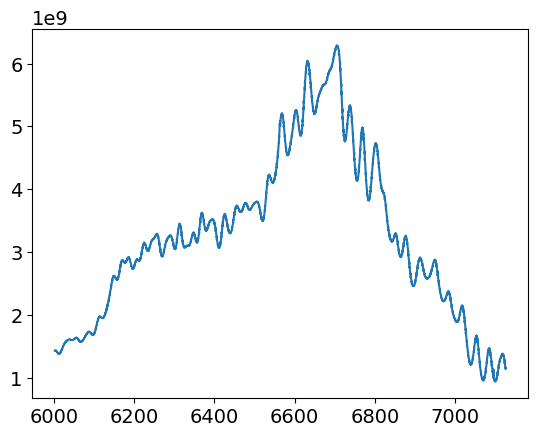

In [19]:
data_old = np.load('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed_u/4/57961_85047.npy')
data = np.load('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed/4/57961_85047.npy')
plt.plot(*data_old)
plt.plot(*data)

In [20]:
np.all(np.isnan(data[1]))

True

In [ ]:
def cliff_correct(ys):
    '''Eliminate power discontinuities between data blocks.'''
    n_nodes = len(ys) // 1024
    reshaped = np.reshape(ys, (n_nodes, 1024)).copy()

    for i in range(n_nodes-1):
        left = reshaped[i]
        right = reshaped[i+1]

        # Fit polynomial to middle 12 points of coarse channel
        if np.all(np.isfinite(left[-14:-2])):
            p = Polynomial.fit(np.arange(12), left[-14:-2], 1) #linear
            y_fit = p(16)
            a = y_fit / right[2]
            for j in range(i+1, n_nodes):
                reshaped[j] *= a
    
    out = np.concatenate(reshaped)
    return out

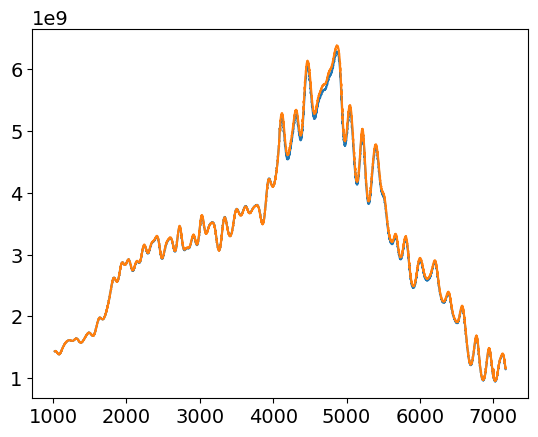

In [22]:
plt.plot(data_old[1])
plt.plot(cliff_correct(data_old[1]))

## iii. Take two!

In [28]:
def cliff_correct(ys):
    '''Eliminate power discontinuities between data blocks.'''
    n_nodes = len(ys) // 1024
    reshaped = np.reshape(ys, (n_nodes, 1024)).copy()

    for i in range(n_nodes-1):
        left = reshaped[i]
        right = reshaped[i+1]

        # Fit polynomial to middle 12 points of coarse channel
        if np.all(np.isfinite(left[-14:-2])):
            p = Polynomial.fit(np.arange(12), left[-14:-2], 1) #linear
            y_fit = p(16)
            a = y_fit / right[2]
            for j in range(i+1, n_nodes):
                reshaped[j] *= a
    
    out = np.concatenate(reshaped)
    return out

def correct(file, bank_dir=None, save_dir=None):
    xs, ys = np.load(os.path.join(bank_dir, file))
    cliffed = cliff_correct(ys)
    new_data = np.array([xs, cliffed])
    np.save(os.path.join(save_dir, file), new_data)

data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed_u'
save_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed'

for bank in range(10):
    bank_data_dir = os.path.join(data_dir, str(bank))
    bank_save_dir = os.path.join(save_dir, str(bank))
    os.makedirs(bank_save_dir, exist_ok=True)
    with Pool(processes=10) as p:
        correct_partial = partial(correct, bank_dir=bank_data_dir, save_dir=bank_save_dir)
        _ = list(tqdm(p.imap_unordered(correct_partial, os.listdir(bank_data_dir)), total=len(os.listdir(bank_data_dir))))

  0%|          | 0/14175 [00:00<?, ?it/s]

  0%|          | 0/13750 [00:00<?, ?it/s]

  0%|          | 0/13403 [00:00<?, ?it/s]

  0%|          | 0/13564 [00:00<?, ?it/s]

  0%|          | 0/13513 [00:00<?, ?it/s]

  0%|          | 0/13395 [00:00<?, ?it/s]

  0%|          | 0/14521 [00:00<?, ?it/s]

  0%|          | 0/14524 [00:00<?, ?it/s]

  0%|          | 0/14490 [00:00<?, ?it/s]

  0%|          | 0/1855 [00:00<?, ?it/s]

In [2]:
plt.rcParams['font.size'] = 14

def plot_heatmap(info, xs, all_spectra, case, bank, start_freq=8000, width=100, n_bins=50, time=False, resid=False, cut=True):
    mask = (xs >= start_freq) & (xs < start_freq + width)
    nans = np.full(xs.shape, np.nan)[mask]
    end_freq = xs[mask][-1]

    info['time_mjd'] = info['time'].apply(lambda mjd: int(mjd.split('_')[0])) #[int(mjd.split('_')[0]) for mjd in info['time']]
    info['cos_theta'] = info['theta'].apply(lambda theta: math.cos(math.radians(theta))) #[math.cos(math.radians(theta)) for theta in info['theta']]
    info['cos_phi'] = info['phi'].apply(lambda phi: math.cos(math.radians(phi))) #[math.cos(math.radians(phi)) for phi in info['phi']]

    var_list = ['time_mjd'] if time else ['cos_theta', 'cos_phi']

    fig = plt.figure(figsize=(12, 6), layout="tight")
    gs = fig.add_gridspec(len(var_list), 2, wspace=0, hspace=0.2, width_ratios=[3, 1])
    axs = gs.subplots().flat

    def create_map(bin_column):
        for i in range(n_bins):
            bin_mask = (info[bin_column] == i).to_numpy()
            spectra = all_spectra[bin_mask][:, mask]
            if spectra.size:
                avg = np.nanmean(spectra, axis=0)
                yield avg
            else:
                yield nans

    for i, var in enumerate(var_list):
        bounds = (min(info['time_mjd']), max(info['time_mjd'])) if var == 'time_mjd' else (-1, 1)
        bins = np.linspace(*bounds, n_bins+1)
        info[f'{var}_bin'] = pd.cut(info[var], bins, labels=False)
            
        heat_map = np.array(list(create_map(f'{var}_bin')))
        if resid:
            heat_map = heat_map - np.nanmean(all_spectra[:, mask], axis=0)

        ax = axs[2*i]
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(np.array(heat_map))
        if resid is not None:
            vmax = max(vmax, -vmin)
            ndigits = -int(math.floor(math.log10(vmax))) + 1
            vmax = round(vmax, ndigits)
            vmin = -vmax
        else:
            vmax = max(vmax, 2-vmin)
            ndigits = -int(math.floor(math.log10(vmax - 1))) + 1
            vmax = round(vmax, ndigits)
            vmin = 2 - vmax
        norm = Normalize(vmin=vmin, vmax=vmax)
        extent = [np.min(xs[mask]), np.max(xs[mask]), *bounds]

        #im0 = axs[0].imshow(theta_map, extent=extent, origin='lower', norm=norm, aspect='auto')
        im1 = ax.imshow(heat_map, extent=extent, cmap='RdBu' if resid is not None else 'viridis', origin='lower', norm=norm, aspect='auto', interpolation='none')
        
        #axs[0].set_ylabel(r'$\mathrm{cos}({\theta})$', fontsize=18)
        if var == 'cos_phi':
            label = r'$\mathrm{cos}({\phi})$'
        elif var == 'cos_theta':
            label = r'$\mathrm{cos}({\theta})$'
        else:
            label = 'Modified JD'

        ax.set_ylabel(label, fontsize=18)
        # for i in bins:
        #     ax.axhline(i, c='r')

        hist_ax = axs[2*i+1]
        nan_mask = np.any(np.isfinite(all_spectra[:, mask]), axis=1)
        info_mask = info[nan_mask]
        hist_ax.hist(info_mask[var], bins=bins, facecolor='lightgray', edgecolor='k', orientation='horizontal')
        hist_ax.set_yticks([])
        hist_ax.set_ylim(*bounds)

        if var != 'time_mjd':
            ax.axhline(0, c='r') # Inward/outward division
            hist_ax.axhline(0, c='r') # Inward/outward division
            ax.set_yticks(np.linspace(-1, 1, 5))
    
    case_str = f'{case} cut' if cut else case
    fig.suptitle(f'Bank {bank} {case_str}: {start_freq:.0f}-{end_freq:.0f} MHz', fontsize=20)
    #ax.set_aspect('auto')

    axs[2*(len(var_list)-1)].set_xlabel(r'$\nu$ [MHz]', fontsize=18)
    axs[2*(len(var_list)-1)+1].set_xlabel('Counts', fontsize=18)

    cax = inset_axes(
        hist_ax,
        width="15%",
        height=f"{100 * len(var_list) + 20 * (len(var_list)-1)}%",
        loc="lower left",
        bbox_to_anchor=(1.05, 0., 1, 1),
        bbox_transform=hist_ax.transAxes,
        borderpad=0
    )
    cbar = fig.colorbar(im1, cax=cax, orientation='vertical')
    cbar.set_label('Normalized Power Residual' if resid is not None else 'Normalized Power', fontsize=18)
    
    return fig

In [38]:
norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized'
norm_cut_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_cut'

info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/all_lscx_info.csv'
info = pd.read_csv(info_dir, sep='\t')

cases = ['decay', 'ann']
banks = np.arange(10)

width = 187.5/2

date = '082526'

os.makedirs(f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/theta_phi', exist_ok=True)

def round_up_to_nearest_10(number):
    return math.ceil(number / 10) * 10

for case in cases:
    is_decay = case == 'decay'
    for cut in [True, False]:
        if cut:
            pdf_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/theta_phi/{case}_cut.pdf'
            data_dir = norm_cut_dir
        else:
            pdf_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/theta_phi/{case}.pdf'
            data_dir = norm_dir
        pdf = PdfPages(pdf_dir)
        
        for bank in banks:
            bank_dir = os.path.join(data_dir, case, str(bank))
            bank_info = info[info['time'].apply(lambda l: l+'.npy').isin(os.listdir(bank_dir))]
            
            xs = np.load(os.path.join(bank_dir, bank_info['time'].tolist()[0]+'.npy'))[0]
            all_spectra = np.array([
                np.load(os.path.join(bank_dir, file+'.npy'))[1]
                for file in bank_info['time']
            ])
            
            start_freqs = np.arange(xs[0], xs[-1], width)

            for start_freq in tqdm(start_freqs, desc=f'Bank {bank} {case} cut' if cut else f'Bank {bank} {case}'):
                fig = plot_heatmap(
                    bank_info,
                    xs,
                    all_spectra,
                    case,
                    bank,
                    start_freq=start_freq,
                    width=width,
                    resid=True,
                    cut=cut
                )
                pdf.savefig(fig, bbox_inches='tight', dpi=72)
                plt.close(fig)

        pdf.close()

Bank 0 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 1 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 2 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 3 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 4 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

...

Bank 5 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 6 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 7 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 8 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 9 ann:   0%|          | 0/16 [00:00<?, ?it/s]

In [3]:
norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized'
norm_cut_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized_cut'

info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/all_lscx_info.csv'
info = pd.read_csv(info_dir, sep='\t')

cases = ['decay', 'ann']
banks = np.arange(10)

width = 187.5/2

date = '082426'

os.makedirs(f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/time', exist_ok=True)

def round_up_to_nearest_10(number):
    return math.ceil(number / 10) * 10

for case in cases:
    is_decay = case == 'decay'
    for cut in [True, False]:
        if cut:
            pdf_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/time/{case}_cut.pdf'
            data_dir = norm_cut_dir
        else:
            pdf_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/plots/heatmaps/{date}/time/{case}.pdf'
            data_dir = norm_dir
        pdf = PdfPages(pdf_dir)
        
        for bank in banks:
            bank_dir = os.path.join(data_dir, case, str(bank))
            bank_info = info[info['time'].apply(lambda l: l+'.npy').isin(os.listdir(bank_dir))]
            
            xs = np.load(os.path.join(bank_dir, bank_info['time'].tolist()[0]+'.npy'))[0]
            all_spectra = np.array([
                np.load(os.path.join(bank_dir, file+'.npy'))[1]
                for file in bank_info['time']
            ])
            
            start_freqs = np.arange(xs[0], xs[-1], width)

            for start_freq in tqdm(start_freqs, desc=f'Bank {bank} {case} cut' if cut else f'Bank {bank} {case}'):
                fig = plot_heatmap(
                    bank_info,
                    xs,
                    all_spectra,
                    case,
                    bank,
                    start_freq=start_freq,
                    width=width,
                    resid=True,
                    time=True,
                    cut=cut
                )
                pdf.savefig(fig, bbox_inches='tight', dpi=72)
                plt.close(fig)

        pdf.close()

Bank 0 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 1 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 2 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 3 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 4 decay cut:   0%|          | 0/16 [00:00<?, ?it/s]

...

Bank 5 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 6 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 7 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 8 ann:   0%|          | 0/16 [00:00<?, ?it/s]

Bank 9 ann:   0%|          | 0/16 [00:00<?, ?it/s]

# **VI. Establishing Blanking Ranges**

[(750, 1320), (1440, 1450), (1520, 1660), (1880, 2260)]
[(1650, 1950), (2110, 2120), (2170, 2260), (2310, 2520), (2550, 2570), (2720, 3160)]
[(3560, 3950), (7640, 7660), (7970, 8440)]
[(7500, 8160), (9730, 9750), (10430, 10600), (11500, 12380)]


Text(0, 0.5, 'SEFD [Jy]')

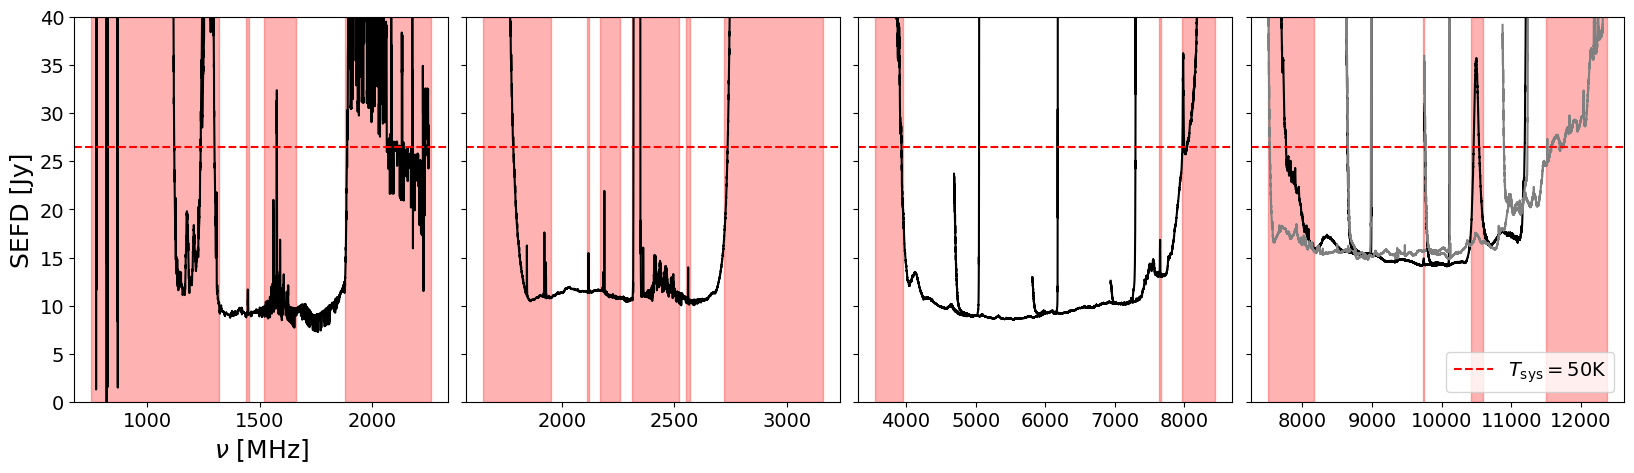

In [58]:
# Plot the median SEFDs
plt.rcParams.update({'font.size': 14})

sefd_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/median_sefds'

fig, axs = plt.subplots(1, 4, figsize=(20,5), sharey=True)
fig.subplots_adjust(wspace=0.05)

k = 1.38e-23  # Boltzmann constant in J/K
JY_PER_J = 1e26 # Jy per Joule
Tsky = 2.728
eta = 0.7
r = 50
a_eff = eta * np.pi * r**2

SEFD_max = 2 * k * JY_PER_J * (50+Tsky) / a_eff # Tsys<50 K metric

start_banks = [0, 1, 2, 6]

blanking_ranges = [
    [
        (750, 1320),
        (1440, 1450),
        (1520, 1660),
        (1880, 2260)
    ],
    [
        (1650, 1950),
        (2110, 2120),
        (2170, 2260),
        (2310, 2520),
        (2550, 2570),
        (2720, 3160)
    ],
    [
        (3560, 3950),
        (7640, 7660),
        (7970, 8440)
    ],
    [
        (7500, 8160),
        (9730, 9750),
        (10430, 10600),
        (11500, 12380)
    ]
]

for bank in range(10):
    bank_dir = os.path.join(sefd_dir, str(bank))
    band_idx = max([i for i, start_bank in enumerate(start_banks) if start_bank <= bank])

    if band_idx == 3:
        path_pre = os.path.join(bank_dir, 'pre23_median.npy')
        path_post = os.path.join(bank_dir, 'post23_median.npy')
        if os.path.exists(path_pre):
            data_pre = np.load(path_pre)
            axs[band_idx].plot(*data_pre, c='k')
        if os.path.exists(path_post):   
            data_post = np.load(path_post)
            axs[band_idx].plot(*data_post, c='gray')
    else:
        path = os.path.join(bank_dir, 'median.npy')
        data = np.load(path)
        axs[band_idx].plot(*data, c='k')

for i, ax in enumerate(axs):
    ax.set_ylim(0,40)
    ax.axhline(SEFD_max, color='r', linestyle='--', label=r'$T_\mathrm{sys} = 50 \mathrm{K}$')
    print(blanking_ranges[i])
    for left, right in blanking_ranges[i]:
        ax.axvspan(left, right, color='red', alpha=.3)

axs[-1].legend(loc='lower right', ncol=2)
axs[0].set_xlabel('$\\nu$ [MHz]', fontsize=18)
axs[0].set_ylabel('SEFD [Jy]', fontsize=18)

(0.0, 25.0)

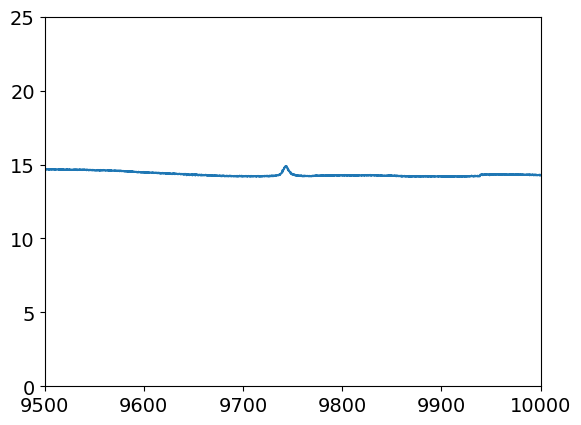

In [59]:
plt.plot(*np.load('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/median_sefds/7/pre23_median.npy'))
plt.xlim(9500, 10000)
plt.ylim(0, 25)

In [40]:
# Start and end of each bank
for bank in range(10):
    bank_dir = os.path.join(sefd_dir, str(bank))    
    path = os.path.join(bank_dir, 'post23_median.npy') if bank >= 6 else os.path.join(bank_dir, 'median.npy')
    xs = np.load(path)[0]
    print(f'Bank {bank}: {(xs[0], xs[-1])}')

Bank 0: (751.5578269958496, 2251.3747215270996)
Bank 1: (1651.5578269958496, 3151.3747215270996)
Bank 2: (3564.0578269958496, 5063.8747215271)
Bank 3: (4689.05782699585, 6188.8747215271)
Bank 4: (5814.05782699585, 7313.8747215271)
Bank 5: (6939.05782699585, 8438.8747215271)
Bank 6: (7501.55782699585, 9001.3747215271)
Bank 7: (8626.55782699585, 10126.3747215271)
Bank 8: (9751.55782699585, 11251.3747215271)
Bank 9: (10876.55782699585, 12376.3747215271)


# **VII. A New Normalization Scheme?**

## Functions

In [4]:
def correlation_matrix(specs):
    '''Implementation of Connolly et al. (1994) correlation matrix formula. Integrated flux normalization.'''
    shape = specs.shape[0]
    cov = np.zeros((shape, shape))
    for i in range(specs.shape[0]):
        for j in range(specs.shape[0]):
            cov[i,j] = np.dot(specs[i], specs[j]) / (np.sum(specs[i]) * np.sum(specs[i]))
    return cov

In [5]:
def klt_connolly(specs):
    cov = correlation_matrix(specs)
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    basis = np.dot(eigenvectors.T, specs)
    scales = np.linalg.norm(basis, axis=1, keepdims=True)
    powers = eigenvalues / np.sum(eigenvalues)
    return basis / scales, powers

## First trial

In [4]:
bank_4_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/calibrator_scans/4'
specs = np.array([np.load(os.path.join(bank_4_dir, time, 'gain.npy'))[1] for time in os.listdir(bank_4_dir)])
specs_test = specs[:, 4000:5000]
basis, powers = klt_connolly(specs_test)

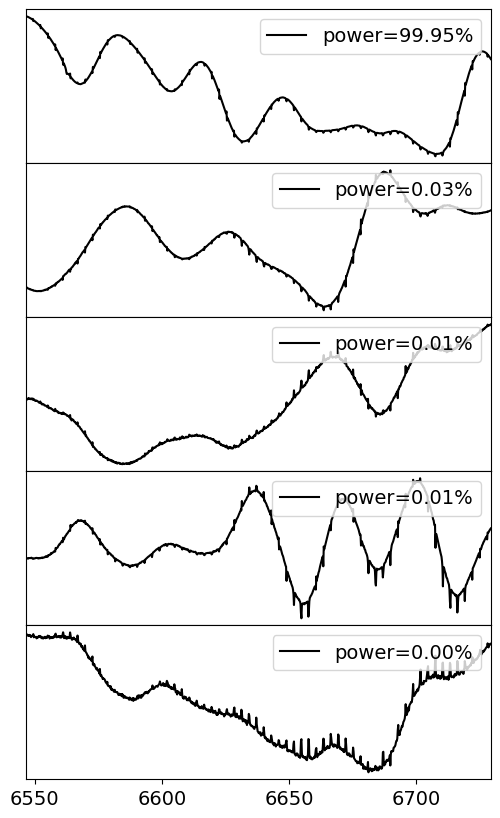

In [5]:
plt.rcParams.update({'font.size': 14})

fig, axs = plt.subplots(5, 1, figsize=(6, 10), sharex=True)
fig.subplots_adjust(hspace=0)

xs = np.load(os.path.join(bank_4_dir, os.listdir(bank_4_dir)[0], 'gain.npy'))[0,4000:5000]

for i, ax in enumerate(axs):
    ax.plot(xs, basis[i], c='k', label=f'power={powers[i]:.2%}')
    ax.set_xlim(xs[0], xs[-1])
    ax.set_yticks([])
    ax.legend(loc='upper right')

  0%|          | 0/54 [00:00<?, ?it/s]

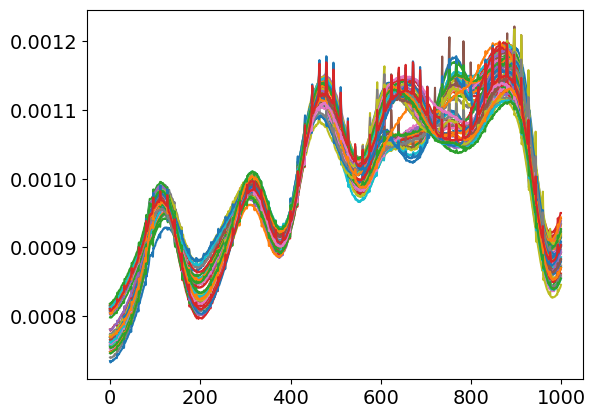

In [7]:
for spec in tqdm(specs_test):
    plt.plot(spec/np.sum(spec))

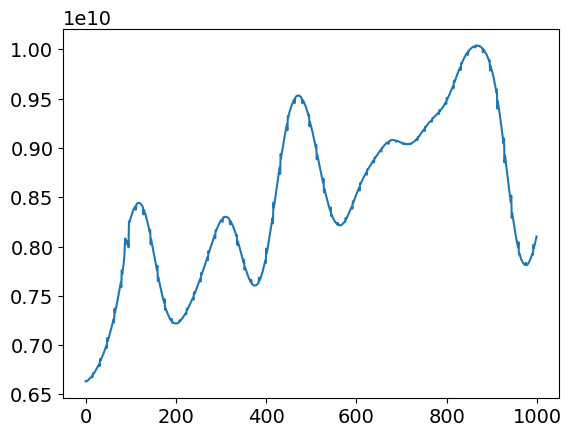

In [8]:
# Test spectrum
path = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed/4/57999_19361.npy'
spec = np.load(path)[1, 4000:5000]
plt.plot(spec)

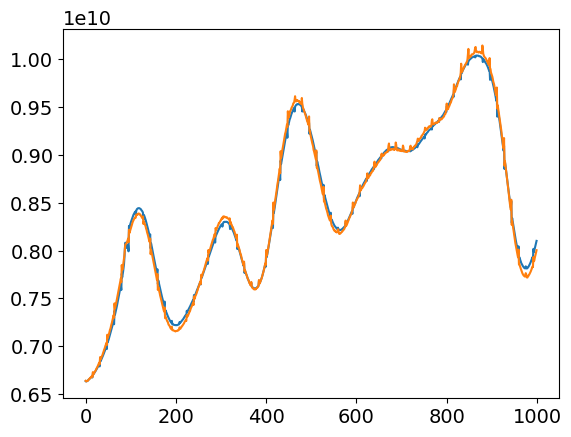

In [10]:
coeffs = np.dot(basis[:5], spec)
est = np.sum(basis[:5] * coeffs[:, np.newaxis], axis=0)
plt.plot(spec)
plt.plot(est)

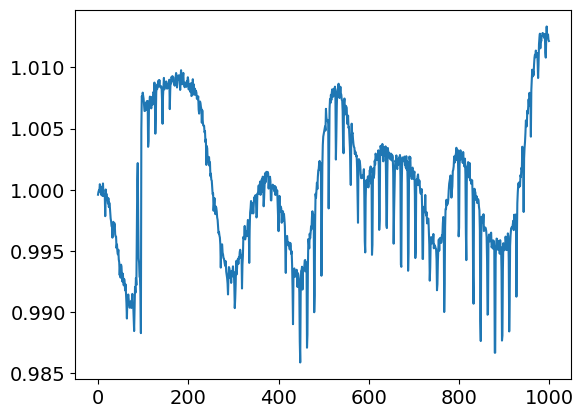

In [11]:
plt.plot(spec / est)

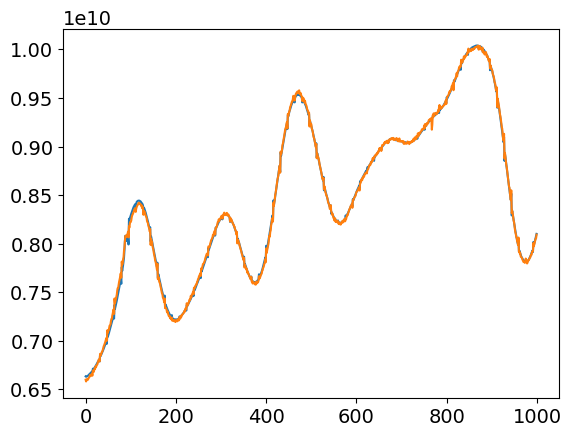

In [12]:
coeffs = np.dot(basis[:20], spec)
est = np.sum(basis[:20] * coeffs[:, np.newaxis], axis=0)
plt.plot(spec)
plt.plot(est)

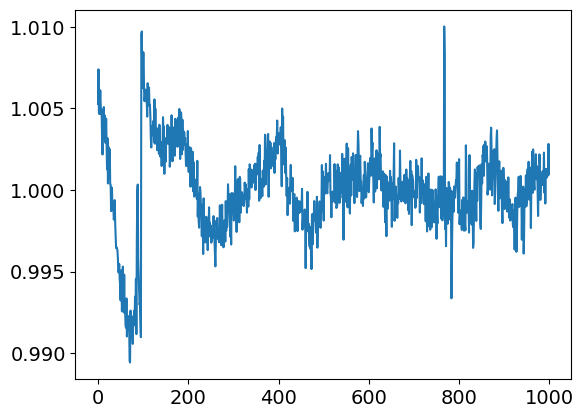

In [13]:
plt.plot(spec / est)

## Mock asymmetry

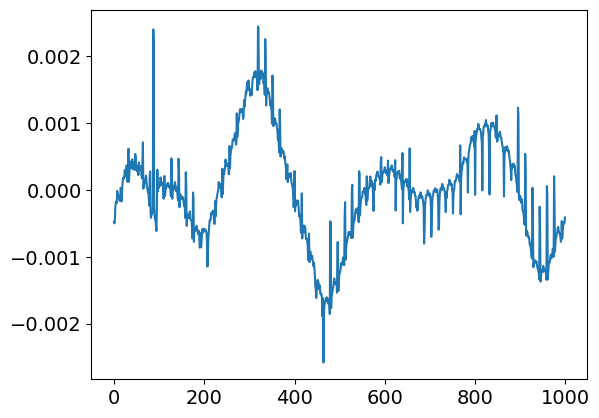

In [17]:
info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/all_lscx_info.csv', sep='\t')
norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed/4/'
info_trimmed = info[info['time'].apply(lambda l: l+'.npy').isin(os.listdir(norm_dir))]
spectra = np.array([np.load(os.path.join(norm_dir, file+'.npy'))[1, 4000:5000] for file in info_trimmed['time']])
nan_mask = np.all(np.isfinite(spectra), axis=1)
spectra = spectra[nan_mask]
info_trimmed = info_trimmed[nan_mask]

# Simple intensity asymmetry (all targets)
def build_asymmetry(specs, info):
    inner = specs[info['phi'] < 90]
    outer = specs[info['phi'] > 90]

    inner_mean = np.mean(inner, axis=0)
    outer_mean = np.mean(outer, axis=0)

    return inner_mean - outer_mean

def kl_correct(specs, basis, n_modes=5):
    new_specs = np.zeros_like(specs)
    for i, spec in enumerate(specs):
        coeffs = np.dot(basis[:n_modes], spec)
        est = np.sum(basis[:n_modes] * coeffs[:, np.newaxis], axis=0)
        new_specs[i] = spec / est
    return new_specs

#asym = build_asymmetry(spectra, info_trimmed)
kl_spectra = kl_correct(spectra, basis, n_modes=5)
kl_asym = build_asymmetry(kl_spectra, info_trimmed)
#plt.plot(asym)
plt.plot(kl_asym)

## Smoothing gains (SEFD procedure)

In [6]:
# Note: 15 bin (1 coarse channel) window for gains.
def smooth(ys, window=15):
    for i in range(16, len(ys)-16, 16):  # Excise the 4 unstable valley points in each coarse channel 
        ys[i] = np.nan
        ys[i+15] = np.nan
        ys[i+1] = np.nan
        ys[i+14] = np.nan
    mask = np.isfinite(ys)
    xs = np.arange(len(ys))
    data_interp = np.interp(xs, xs[mask], ys[mask])
    smoothed = savgol_filter(data_interp, window, 3, mode='nearest')
    return smoothed

bank_4_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/calibrator_scans/4'
specs = np.array([np.load(os.path.join(bank_4_dir, time, 'gain.npy'))[1] for time in os.listdir(bank_4_dir)])
specs_test = specs[:, 4000:5000]
specs_smoothed = np.array([smooth(spec) for spec in specs_test])
basis, powers = klt_connolly(specs_smoothed)

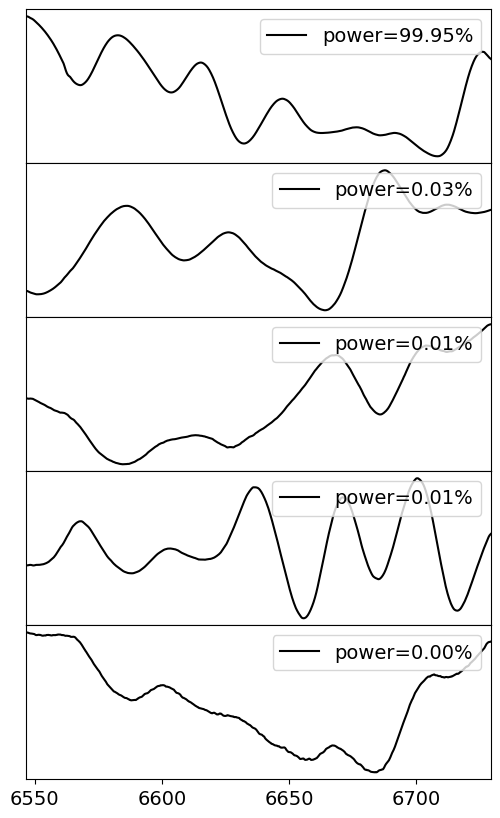

In [7]:
plt.rcParams.update({'font.size': 14})

fig, axs = plt.subplots(5, 1, figsize=(6, 10), sharex=True)
fig.subplots_adjust(hspace=0)

xs = np.load(os.path.join(bank_4_dir, os.listdir(bank_4_dir)[0], 'gain.npy'))[0,4000:5000]

for i, ax in enumerate(axs):
    ax.plot(xs, basis[i], c='k', label=f'power={powers[i]:.2%}')
    ax.set_xlim(xs[0], xs[-1])
    ax.set_yticks([])
    ax.legend(loc='upper right')

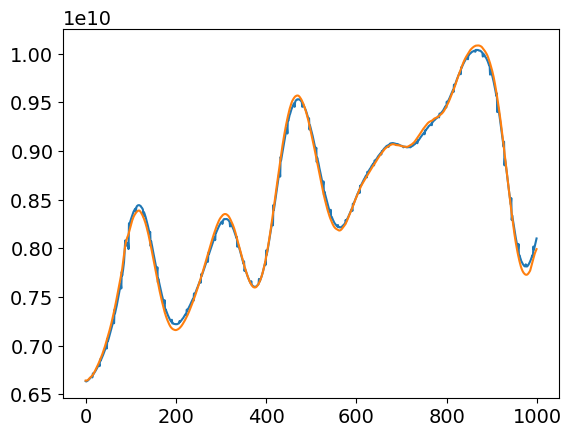

In [8]:
path = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed/4/57999_19361.npy'
spec = np.load(path)[1, 4000:5000]
coeffs = np.dot(basis[:5], spec)
est = np.sum(basis[:5] * coeffs[:, np.newaxis], axis=0)
plt.plot(spec)
plt.plot(est)

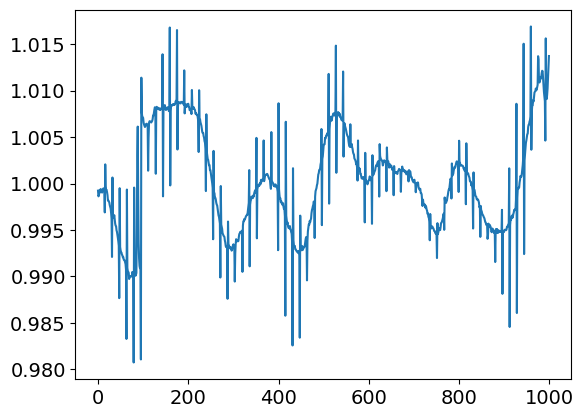

In [9]:
plt.plot(spec / est)

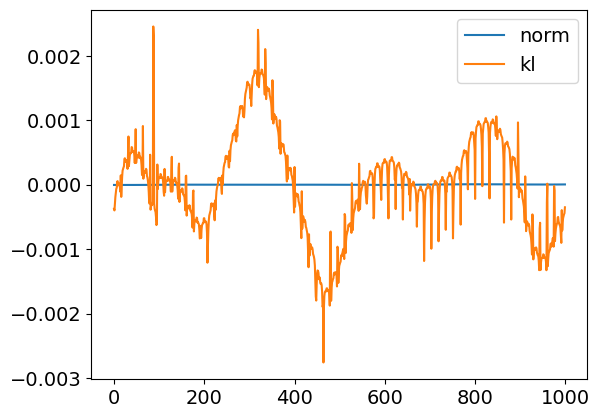

In [10]:
info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/all_lscx_info.csv', sep='\t')
norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed/4/'
info_trimmed = info[info['time'].apply(lambda l: l+'.npy').isin(os.listdir(norm_dir))]
spectra = np.array([np.load(os.path.join(norm_dir, file+'.npy'))[1, 4000:5000] for file in info_trimmed['time']])
nan_mask = np.all(np.isfinite(spectra), axis=1)
spectra = spectra[nan_mask]
info_trimmed = info_trimmed[nan_mask]

# Simple intensity asymmetry (all targets)
def build_asymmetry(specs, info):
    inner = specs[info['phi'] < 90]
    outer = specs[info['phi'] > 90]

    inner_mean = np.mean(inner, axis=0)
    outer_mean = np.mean(outer, axis=0)

    return inner_mean - outer_mean

def kl_correct(specs, basis, n_modes=5):
    new_specs = np.zeros_like(specs)
    for i, spec in enumerate(specs):
        coeffs = np.dot(basis[:n_modes], spec)
        est = np.sum(basis[:n_modes] * coeffs[:, np.newaxis], axis=0)
        new_specs[i] = spec / est
    return new_specs

norm_spectra = np.array([spec / np.sum(spec) for spec in spectra])
norm_asym = build_asymmetry(norm_spectra, info_trimmed)
kl_spectra = kl_correct(spectra, basis, n_modes=5)
kl_asym = build_asymmetry(kl_spectra, info_trimmed)
plt.plot(norm_asym, label='norm')
plt.plot(kl_asym, label='kl')
plt.legend()

In [11]:
norm_spectra

array([[0.0008349 , 0.00083503, 0.00083615, ..., 0.00091652, 0.00091337,
        0.00091021],
       [0.00083487, 0.00083527, 0.00083651, ..., 0.0009162 , 0.000913  ,
        0.00090983],
       [0.00083466, 0.00083479, 0.00083582, ..., 0.00091669, 0.00091341,
        0.00091067],
       ...,
       [0.00079652, 0.00079545, 0.00079613, ..., 0.00091425, 0.00091639,
        0.00091871],
       [0.00079673, 0.0007955 , 0.00079617, ..., 0.00091422, 0.00091642,
        0.00091861],
       [0.00079689, 0.00079581, 0.00079656, ..., 0.00091378, 0.00091626,
        0.00091834]])

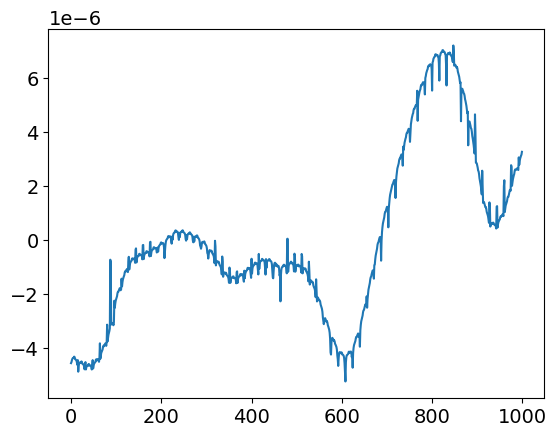

In [13]:
plt.plot(norm_asym)

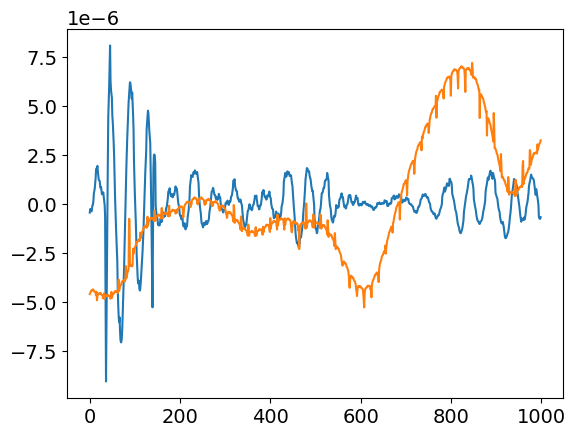

In [20]:
real_norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized/decay/4/'
info_trimmed = info[info['time'].apply(lambda l: l+'.npy').isin(os.listdir(norm_dir))]
normalized_spectra = np.array([np.load(os.path.join(real_norm_dir, file+'.npy'))[1, 4000:5000] for file in info_trimmed['time']])[nan_mask]
info_trimmed = info_trimmed[nan_mask]

real_norm_asym = build_asymmetry(normalized_spectra, info_trimmed)
plt.plot(real_norm_asym, label='weighted ps')
plt.plot(norm_asym, label='integral')

### All of bank 4

In [21]:
# Simple intensity asymmetry (all targets)
def build_asymmetry(specs, info):
    inner = specs[info['phi'] < 90]
    outer = specs[info['phi'] > 90]

    inner_mean = np.nanmean(inner, axis=0)
    outer_mean = np.nanmean(outer, axis=0)

    return (inner_mean - outer_mean) / (inner_mean + outer_mean)

norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed/4/'
real_norm_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized/decay/4/'
info_trimmed = info[info['time'].apply(lambda l: l+'.npy').isin(os.listdir(norm_dir))]
spectra = np.array([np.load(os.path.join(norm_dir, file+'.npy'))[1] for file in info_trimmed['time']])
normalized_spectra = np.array([np.load(os.path.join(real_norm_dir, file+'.npy'))[1] for file in info_trimmed['time']])

In [25]:
norm_spectra = np.array([spec / np.sum(spec) for spec in spectra])
asym = build_asymmetry(norm_spectra, info_trimmed)
norm_asym = build_asymmetry(normalized_spectra, info_trimmed)
plt.plot(asym, label='integral')
plt.plot(norm_asym, label='norm')
plt.legend()
plt.ylim(-1e-1, 1e-1)

: 

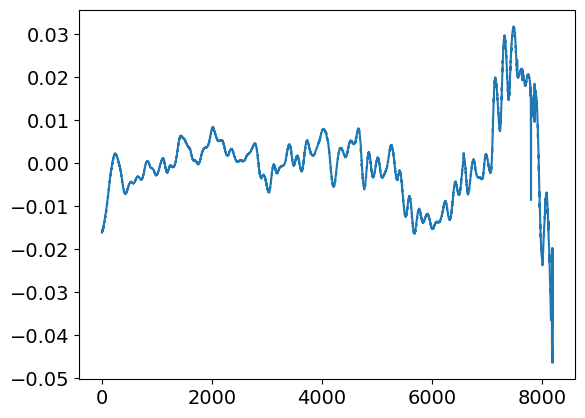

In [24]:
plt.plot(asym)

# **MISCELLANEA**

## Optimization weirdness...

In [4]:
template_spectra = np.load('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/target_selection/082426/template_spectra.npy')

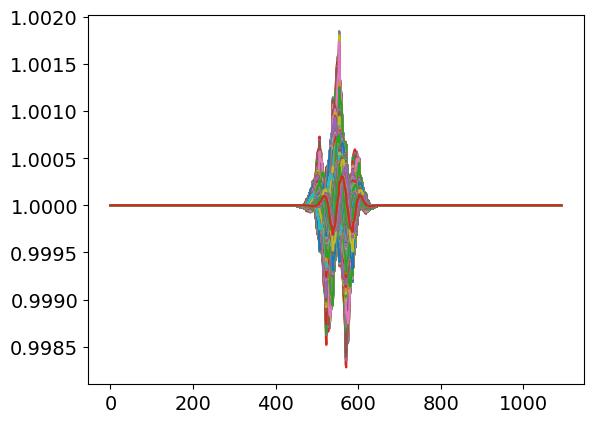

In [7]:
for spec in template_spectra:
    plt.plot(spec)

In [8]:
def build_asymmetry(specs, state, mask): #template=False
    '''Form asymmetry from a given state.'''
    inner = (state == 1) & mask
    outer = (state == 1) & ~mask

    # specs = template_spectra if template else spectra

    # inner_mean, outer_mean = get_means(specs, inner, outer)
    inner_slice = specs[inner, :]
    outer_slice = specs[outer, :]
    # inner_mean = np.mean(inner_slice, axis=0)
    # outer_mean = np.mean(outer_slice, axis=0)
    inner_mean = np.zeros(specs.shape[1])
    outer_mean = np.zeros(specs.shape[1])
    
    for j in range(specs.shape[1]):
        inner_mean[j] = inner_slice[:, j].mean()
        outer_mean[j] = outer_slice[:, j].mean()

    asymmetry = (inner_mean - outer_mean) / (inner_mean + outer_mean)

    # if template:
    #     # Smoothing the template with a spline (Aya)
    #     xs_temp = np.arange(len(asymmetry))
    #     asymmetry = scipy.interpolate.make_interp_spline(xs_temp[::15], asymmetry[::15], k=3)(xs_temp)
    
    return asymmetry

In [10]:
info_path = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/all_lscx_info.csv'
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed'

info = pd.read_csv(info_path, sep='\t')

# Bank info
bank_dir = os.path.join(data_dir, '3')
bank_info = info[info['time'].apply(lambda l: l + '.npy').isin(os.listdir(bank_dir))]
print(len(bank_info))

13564


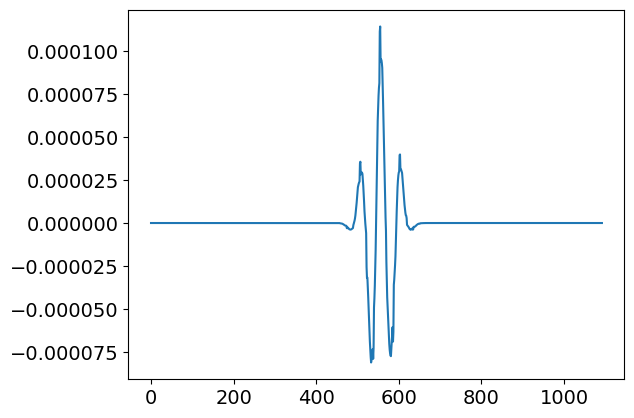

In [11]:
state = np.ones(len(bank_info))
mask = (bank_info['phi'] < 90).to_numpy()
asym = build_asymmetry(template_spectra, state, mask)
plt.plot(asym)

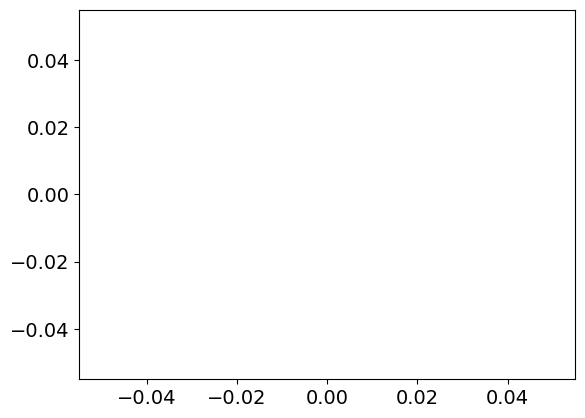

In [12]:
uninj_norm_spectra = np.load('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/target_selection/082426/uninj_norm_spectra.npy')
uninj_asym = build_asymmetry(uninj_norm_spectra, state, mask)
plt.plot(uninj_asym)

In [15]:
np.sum(np.isnan(uninj_norm_spectra)) / uninj_norm_spectra.size

0.14602039261786715

In [18]:
def build_asymmetry(specs, state, mask): #template=False
    '''Form asymmetry from a given state.'''
    inner = (state == 1) & mask
    outer = (state == 1) & ~mask

    # specs = template_spectra if template else spectra

    # inner_mean, outer_mean = get_means(specs, inner, outer)
    inner_slice = specs[inner, :]
    outer_slice = specs[outer, :]
    # inner_mean = np.mean(inner_slice, axis=0)
    # outer_mean = np.mean(outer_slice, axis=0)
    inner_mean = np.zeros(specs.shape[1])
    outer_mean = np.zeros(specs.shape[1])
    
    for j in range(specs.shape[1]):
        inner_mean[j] = np.nanmean(inner_slice[:, j])
        outer_mean[j] = np.nanmean(outer_slice[:, j])

    asymmetry = (inner_mean - outer_mean) / (inner_mean + outer_mean)

    # if template:
    #     # Smoothing the template with a spline (Aya)
    #     xs_temp = np.arange(len(asymmetry))
    #     asymmetry = scipy.interpolate.make_interp_spline(xs_temp[::15], asymmetry[::15], k=3)(xs_temp)
    
    return asymmetry

(-1e-06, 1e-06)

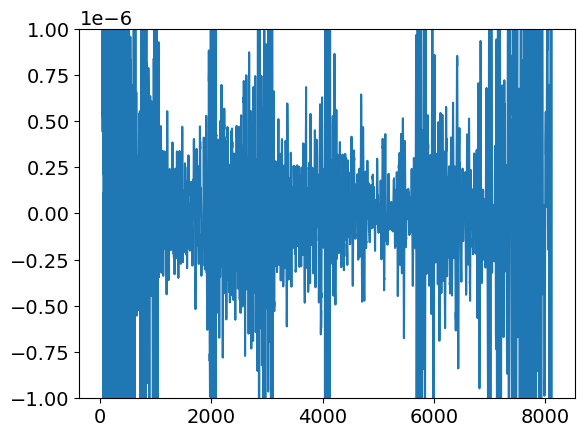

In [20]:
uninj_asym = build_asymmetry(uninj_norm_spectra, state, mask)
plt.plot(uninj_asym)
plt.ylim(-1e-6, 1e-6)

## Timing asymmetry and wammsd functions

In [23]:
import time

In [21]:
@njit
def build_asymmetry(specs, state, mask): #template=False
    '''Form asymmetry from a given state.'''
    inner = (state == 1) & mask
    outer = (state == 1) & ~mask

    # specs = template_spectra if template else spectra

    # inner_mean, outer_mean = get_means(specs, inner, outer)
    inner_slice = specs[inner, :]
    outer_slice = specs[outer, :]
    # inner_mean = np.mean(inner_slice, axis=0)
    # outer_mean = np.mean(outer_slice, axis=0)
    inner_mean = np.zeros(specs.shape[1])
    outer_mean = np.zeros(specs.shape[1])
    
    for j in range(specs.shape[1]):
        inner_mean[j] = np.nanmean(inner_slice[:, j])
        outer_mean[j] = np.nanmean(outer_slice[:, j])

    asymmetry = (inner_mean - outer_mean) / (inner_mean + outer_mean)

    # if template:
    #     # Smoothing the template with a spline (Aya)
    #     xs_temp = np.arange(len(asymmetry))
    #     asymmetry = scipy.interpolate.make_interp_spline(xs_temp[::15], asymmetry[::15], k=3)(xs_temp)
    
    return asymmetry

@njit
def wammsd_dynamic(asymmetry, freqs, freq_diff=0.18, factor=1e-3):
    '''Weighted average moving median squared deviation. Window width is in MHz.'''
    # Basic filter (pass middle 6 nodes)
    def filter(i, length):
        if i < (length / 8):
            return 8 * i / length
        elif i > (7 * length / 8):
            return 8 * (1 - i / length)
        else:
            return 1
    
    #msds = list(map(msd, range(500, len(asymmetry)-500)))
    #inds = np.arange(half_width_bin, len(asymmetry)-half_width_bin)
    msds = np.zeros(len(freqs))
    filt = np.zeros(len(freqs))
    for i in range(len(freqs)):
    #for i, freq in enumerate(freqs):
        half_width_bin = int(2 * factor * freqs[i] / freq_diff)
        window = asymmetry[max(0, i-half_width_bin):min(len(freqs)-1, i+half_width_bin)]
        devs = np.zeros(len(window))
        for j in range(len(window)):
            devs[j] = np.abs(window[j]) ** 2
        msds[i] = np.nanmedian(devs)
        filt[i] = filter(i, len(freqs))

    nan_mask = ~np.isnan(msds)
    msds, filt = msds[nan_mask], filt[nan_mask]
    wammsd = np.average(msds, weights=filt)
    return wammsd #np.sqrt(wammsd)

In [24]:
uninj_norm_spectra = np.load('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/target_selection/082426/uninj_norm_spectra.npy')
info_path = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/all_lscx_info.csv'
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/preprocessed'

info = pd.read_csv(info_path, sep='\t')

bank_dir = os.path.join(data_dir, '3')
bank_info = info[info['time'].apply(lambda l: l + '.npy').isin(os.listdir(bank_dir))]
state = np.ones(len(bank_info))
mask = (bank_info['phi'] < 90).to_numpy()

_ = build_asymmetry(uninj_norm_spectra, state, mask)

start = time.perf_counter()
_ = build_asymmetry(uninj_norm_spectra, state, mask)
end = time.perf_counter()
end - start

2.890798570588231

In [26]:
freqs = np.load('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/normalized/decay/3/57505_80457.npy')[0]
asym = build_asymmetry(uninj_norm_spectra, state, mask)

_ = wammsd_dynamic(asym, freqs)

start = time.perf_counter()
_ = wammsd_dynamic(asym, freqs)
end = time.perf_counter()
end - start

0.020938357338309288

### Build_asymmetry optimization

In [35]:
from numba import objmode
@njit
def build_asymmetry(specs, state, mask): #template=False
    '''Form asymmetry from a given state.'''
    with objmode(start='f8'):
        start = time.perf_counter()
    inner = (state == 1) & mask
    outer = (state == 1) & ~mask
    with objmode():
        print('masks: {}'.format(time.perf_counter() - start))

    # specs = template_spectra if template else spectra

    with objmode(start='f8'):
        start = time.perf_counter()
    # inner_mean, outer_mean = get_means(specs, inner, outer)
    inner_slice = specs[inner, :]
    outer_slice = specs[outer, :]
    # inner_mean = np.mean(inner_slice, axis=0)
    # outer_mean = np.mean(outer_slice, axis=0)
    inner_mean = np.zeros(specs.shape[1])
    outer_mean = np.zeros(specs.shape[1])
    with objmode():
        print('slice: {}'.format(time.perf_counter() - start))   
    
    with objmode(start='f8'):
        start = time.perf_counter()
    for j in range(specs.shape[1]):
        inner_mean[j] = np.nanmean(inner_slice[:, j])
        outer_mean[j] = np.nanmean(outer_slice[:, j])
    with objmode():
        print('means: {}'.format(time.perf_counter() - start))

    with objmode(start='f8'):
        start = time.perf_counter()
    asymmetry = (inner_mean - outer_mean) / (inner_mean + outer_mean)
    with objmode():
        print('form: {}'.format(time.perf_counter() - start))

    # if template:
    #     # Smoothing the template with a spline (Aya)
    #     xs_temp = np.arange(len(asymmetry))
    #     asymmetry = scipy.interpolate.make_interp_spline(xs_temp[::15], asymmetry[::15], k=3)(xs_temp)
    
    return asymmetry

In [38]:
huh = build_asymmetry(uninj_norm_spectra, state, mask)

masks: 9.797513484954834e-05
slice: 0.4247813271358609
means: 2.387001533061266
form: 0.00019770953804254532


In [64]:
@njit
def build_asymmetry(specs, state, mask): #template=False
    '''Form asymmetry from a given state.'''
    with objmode(start='f8'):
        start = time.perf_counter()
    inner = (state == 1) & mask
    outer = (state == 1) & ~mask
    with objmode():
        print('masks: {}'.format(time.perf_counter() - start))

    # specs = template_spectra if template else spectra

    # with objmode(start='f8'):
    #     start = time.perf_counter()
    # # inner_mean, outer_mean = get_means(specs, inner, outer)
    # inner_slice = specs[inner, :]
    # outer_slice = specs[outer, :]
    # # inner_mean = np.mean(inner_slice, axis=0)
    # # outer_mean = np.mean(outer_slice, axis=0)
    # inner_mean = np.zeros(specs.shape[1])
    # outer_mean = np.zeros(specs.shape[1])
    # with objmode():
    #     print('slice: {}'.format(time.perf_counter() - start))   

    with objmode(start='f8'):
        start = time.perf_counter()
    
    inner_mean = np.zeros(specs.shape[1], dtype=np.float64)
    outer_mean = np.zeros(specs.shape[1], dtype=np.float64)
    for j in range(specs.shape[1]):
        inner_sum = 0.0
        outer_sum = 0.0
        inner_total = 0
        outer_total = 0

        for k in range(specs.shape[0]):
            val = specs[k, j]
            if not math.isnan(val):
                if inner[k]:
                    inner_sum += val
                    inner_total += 1
                elif outer[k]:
                    outer_sum += val
                    outer_total += 1
        inner_mean[j] = inner_sum / inner_total if inner_total > 0 else np.nan
        outer_mean[j] = outer_sum / outer_total if outer_total > 0 else np.nan
    
    with objmode():
        print('means: {}'.format(time.perf_counter() - start))

    with objmode(start='f8'):
        start = time.perf_counter()
    asymmetry = (inner_mean - outer_mean) / (inner_mean + outer_mean)
    with objmode():
        print('form: {}'.format(time.perf_counter() - start))

    # if template:
    #     # Smoothing the template with a spline (Aya)
    #     xs_temp = np.arange(len(asymmetry))
    #     asymmetry = scipy.interpolate.make_interp_spline(xs_temp[::15], asymmetry[::15], k=3)(xs_temp)
    
    return asymmetry

In [65]:
huh = build_asymmetry(uninj_norm_spectra, state, mask)

masks: 0.0019163591787219048
means: 2.2167905708774924
form: 0.001994413323700428


In [66]:
np.all(np.isnan(huh))

False

(-1e-06, 1e-06)

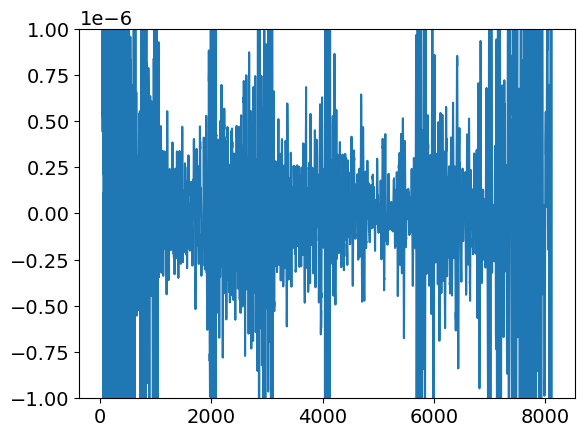

In [67]:
plt.plot(huh)
plt.ylim(-1e-6, 1e-6)

In [68]:
uninj_norm_spectra.shape

(13564, 8192)

In [69]:
np.asfortranarray(uninj_norm_spectra)

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [70]:
huh = build_asymmetry(np.asfortranarray(uninj_norm_spectra), state, mask)

masks: 0.0019220756366848946
means: 0.23893622029572725
form: 0.002002215012907982


In [71]:
huh = build_asymmetry(uninj_norm_spectra, state, mask)

masks: 8.623488247394562e-05
means: 2.246022116392851
form: 0.0001645367592573166


## Optimized asymmetry up close

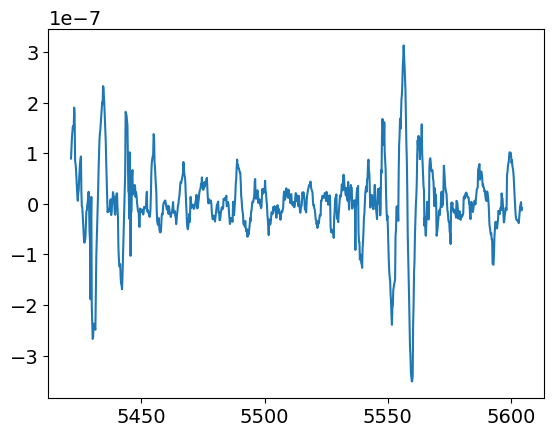

: 

In [ ]:
asym = np.load('/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/target_selection/082426/objective_wammsd/best_asymmetry.npy')
plt.plot(*asym[:, 4000:5000])

## Smoothed median sefds

### Smoothing

In [18]:
from scipy.signal import savgol_filter

sefd_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/median_sefds'
start_banks = [0, 1, 2, 6]

def smooth(data):
    for i in range(16, len(data[1])-16, 16):  # Excise the 4 unstable valley points in each coarse channel 
        data[1, i] = np.nan
        data[1, i+15] = np.nan
        data[1, i+1] = np.nan
        data[1, i+14] = np.nan
    mask = np.isfinite(data[1])
    data_interp = np.interp(data[0], data[0][mask], data[1][mask])
    data[1] = savgol_filter(data_interp, 79, 3, mode='nearest')
    return data


for bank in range(10):
    bank_dir = os.path.join(sefd_dir, str(bank))
    band_idx = max([i for i, start_bank in enumerate(start_banks) if start_bank <= bank])
    if band_idx == 3:
        path_pre = os.path.join(bank_dir, 'pre23_median')
        path_post = os.path.join(bank_dir, 'post23_median')
        if os.path.exists(path_pre+'.npy'):
            data_pre = np.load(path_pre+'.npy')
            data_smoothed = smooth(data_pre)
            np.save(path_pre+'_smoothed.npy', data_smoothed)

        if os.path.exists(path_post+'.npy'):   
            data_post = np.load(path_post+'.npy')
            data_smoothed = smooth(data_post)
            np.save(path_post+'_smoothed.npy', data_smoothed)

    else:
        path = os.path.join(bank_dir, 'median.npy')
        data = np.load(path)
        data_smoothed = smooth(data)
        np.save(os.path.join(bank_dir, 'median_smoothed.npy'), data)

### Plotting

[(750, 1320), (1440, 1450), (1520, 1660), (1880, 2260)]
[(1650, 1950), (2110, 2120), (2170, 2260), (2310, 2520), (2550, 2570), (2720, 3160)]
[(3560, 3950), (7640, 7660), (7970, 8440)]
[(7500, 8160), (9730, 9750), (10430, 10600), (11500, 12380)]


Text(0, 0.5, 'SEFD [Jy]')

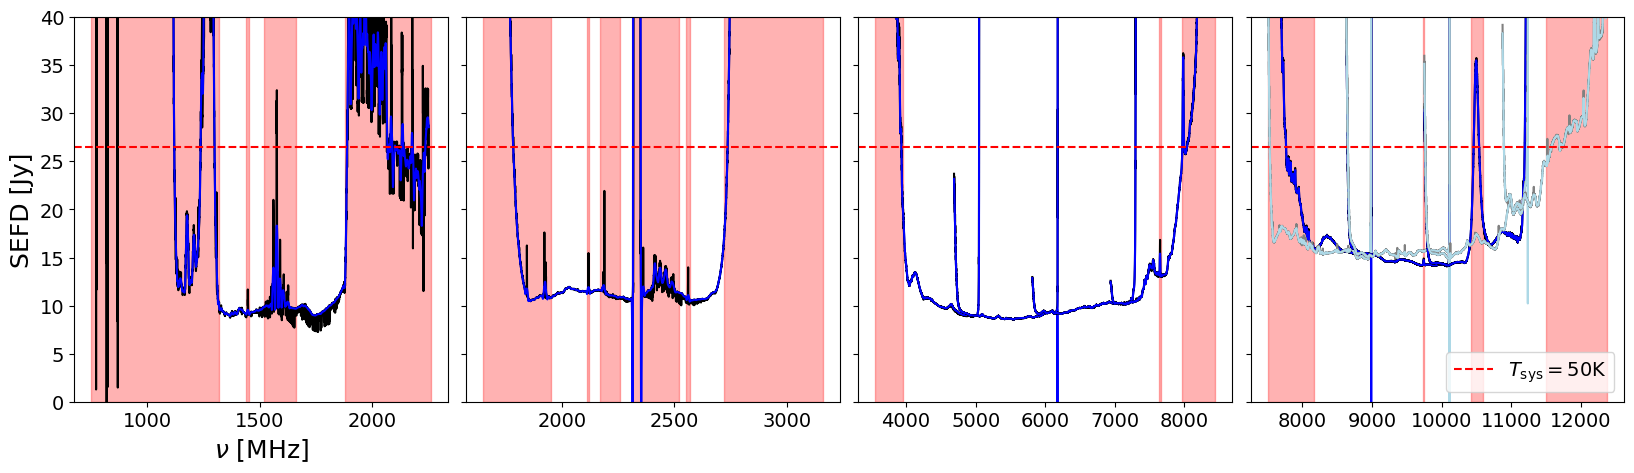

In [19]:
# Plot the median SEFDs
plt.rcParams.update({'font.size': 14})

sefd_dir = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/median_sefds'

fig, axs = plt.subplots(1, 4, figsize=(20,5), sharey=True)
fig.subplots_adjust(wspace=0.05)

k = 1.38e-23  # Boltzmann constant in J/K
JY_PER_J = 1e26 # Jy per Joule
Tsky = 2.728
eta = 0.7
r = 50
a_eff = eta * np.pi * r**2

SEFD_max = 2 * k * JY_PER_J * (50+Tsky) / a_eff # Tsys<50 K metric

start_banks = [0, 1, 2, 6]

blanking_ranges = [
    [
        (750, 1320),
        (1440, 1450),
        (1520, 1660),
        (1880, 2260)
    ],
    [
        (1650, 1950),
        (2110, 2120),
        (2170, 2260),
        (2310, 2520),
        (2550, 2570),
        (2720, 3160)
    ],
    [
        (3560, 3950),
        (7640, 7660),
        (7970, 8440)
    ],
    [
        (7500, 8160),
        (9730, 9750),
        (10430, 10600),
        (11500, 12380)
    ]
]

for bank in range(10):
    bank_dir = os.path.join(sefd_dir, str(bank))
    band_idx = max([i for i, start_bank in enumerate(start_banks) if start_bank <= bank])

    if band_idx == 3:
        path_pre = os.path.join(bank_dir, 'pre23_median')
        path_post = os.path.join(bank_dir, 'post23_median')
        if os.path.exists(path_pre+'.npy'):
            data_pre = np.load(path_pre+'.npy')
            data_pre_smooth = np.load(path_pre+'_smoothed.npy')
            axs[band_idx].plot(*data_pre, c='k')
            axs[band_idx].plot(*data_pre_smooth, c='blue')

        if os.path.exists(path_post+'.npy'):   
            data_post = np.load(path_post+'.npy')
            data_post_smooth = np.load(path_post+'_smoothed.npy')
            axs[band_idx].plot(*data_post, c='gray')
            axs[band_idx].plot(*data_post_smooth, c='lightblue')
    else:
        path = os.path.join(bank_dir, 'median.npy')
        path_smooth = os.path.join(bank_dir, 'median_smoothed.npy')
        data = np.load(path)
        data_smooth = np.load(path_smooth)
        axs[band_idx].plot(*data, c='k')
        axs[band_idx].plot(*data_smooth, c='blue')

for i, ax in enumerate(axs):
    ax.set_ylim(0,40)
    ax.axhline(SEFD_max, color='r', linestyle='--', label=r'$T_\mathrm{sys} = 50 \mathrm{K}$')
    print(blanking_ranges[i])
    for left, right in blanking_ranges[i]:
        ax.axvspan(left, right, color='red', alpha=.3)

axs[-1].legend(loc='lower right', ncol=2)
axs[0].set_xlabel('$\\nu$ [MHz]', fontsize=18)
axs[0].set_ylabel('SEFD [Jy]', fontsize=18)

### Up close and personal...

(8.0, 11.0)

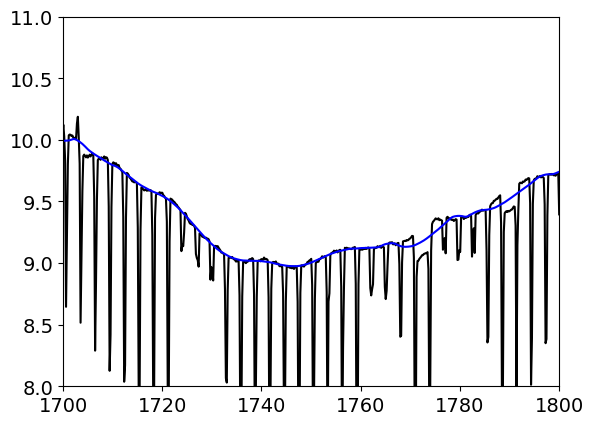

In [20]:
path = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/median_sefds/0/median.npy'
path_smooth = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/median_sefds/0/median_smoothed.npy'

fig, ax = plt.subplots()
ax.plot(*np.load(path), c='k')
ax.plot(*np.load(path_smooth), c='blue')
ax.set_xlim(1700, 1800)
ax.set_ylim(8, 11)

(8.7, 9.1)

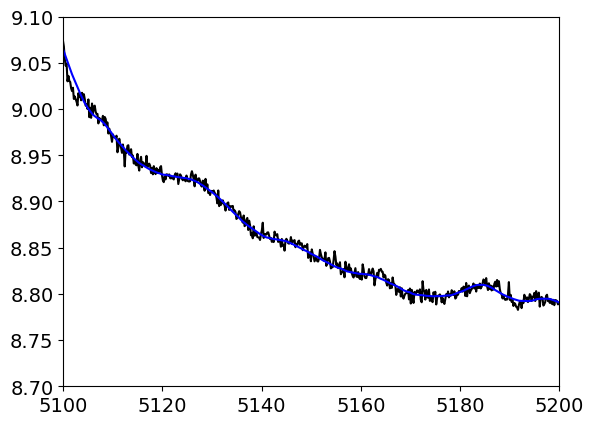

In [21]:
path = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/median_sefds/3/median.npy'
path_smooth = '/home/dataadmin/GBTData/SharedDataDirectory/lscx_081526/data/median_sefds/3/median_smoothed.npy'

fig, ax = plt.subplots()
ax.plot(*np.load(path), c='k')
ax.plot(*np.load(path_smooth), c='blue')
ax.set_xlim(5100, 5200)
ax.set_ylim(8.7, 9.1)